# Análisis Exploratorio - Dataset Sintético BioCatch para Detección de Vishing

**Iniciativa Anti-Vishing:** Modelo de Aprendizaje Automático para Detección de Patrones de Comportamiento


## Objetivo de este notebook

Realizar un análisis exploratorio estadístico del dataset sintético que simula los datos comportamentales recopilados por BioCatch durante sesiones bancarias en la app MiBancolombia. El análisis busca:

1. **Validar la calidad del dataset sintético** — distribuciones, valores nulos, outliers, consistencia
2. **Caracterizar las diferencias** entre sesiones legítimas y sesiones de vishing
3. **Identificar las features más discriminativas** para el modelo de clasificación
4. **Explorar correlaciones y patrones multivariados** que informen la estrategia de modelado
5. **Generar hipótesis accionables** para la Fase 3 (modelado)


## 1. Setup y Carga de Datos

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, chi2_contingency, pointbiserialr
import warnings
warnings.filterwarnings('ignore')

# Configuración visual
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

COLORS = {'legit': '#2ecc71', 'vishing': '#e74c3c', 'neutral': '#3498db'}
LABEL_MAP = {0: 'Legítima', 1: 'Vishing'}

print('✅ Librerías cargadas')

✅ Librerías cargadas


In [30]:
# Cargar dataset
df = pd.read_csv('raw_data/dataset_sintetico_biocatch_vishing_overlap.csv', parse_dates=['session_timestamp'])

# Separar subsets
df_legit = df[df['is_vishing'] == 0]
df_vishing = df[df['is_vishing'] == 1]

print(f'Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'Sesiones legítimas: {len(df_legit):,} ({len(df_legit)/len(df)*100:.1f}%)')
print(f'Sesiones vishing:   {len(df_vishing):,} ({len(df_vishing)/len(df)*100:.1f}%)')
print(f'\nImbalance ratio: 1:{len(df_legit)//len(df_vishing)}')

Dataset cargado: 50,000 filas × 61 columnas
Sesiones legítimas: 47,500 (95.0%)
Sesiones vishing:   2,500 (5.0%)

Imbalance ratio: 1:19


## 2. Validación de Calidad del Dataset

Antes de cualquier análisis, validamos integridad: nulos, duplicados, tipos, rangos.

In [31]:
# 2.1 Info general y tipos
print('='*60)
print('TIPOS DE DATOS')
print('='*60)
type_counts = df.dtypes.value_counts()
for dtype, count in type_counts.items():
    print(f'  {dtype}: {count} columnas')

print(f'\n{"="*60}')
print('VALORES NULOS')
print('='*60)
null_counts = df.isnull().sum()
if null_counts.sum() == 0:
    print('  ✅ Cero valores nulos en todo el dataset')
else:
    print(null_counts[null_counts > 0])

print(f'\n{"="*60}')
print('DUPLICADOS')
print('='*60)
dup_sessions = df['session_id'].duplicated().sum()
print(f'  Session IDs duplicados: {dup_sessions}')
print(f'  Filas completamente duplicadas: {df.duplicated().sum()}')

print(f'\n{"="*60}')
print('CLIENTES ÚNICOS')
print('='*60)
print(f'  Total customers únicos: {df["customer_id"].nunique():,}')
print(f'  Sesiones por customer (promedio): {df.groupby("customer_id").size().mean():.2f}')

TIPOS DE DATOS
  int64: 28 columnas
  float64: 26 columnas
  str: 6 columnas
  datetime64[us]: 1 columnas

VALORES NULOS
  ✅ Cero valores nulos en todo el dataset

DUPLICADOS
  Session IDs duplicados: 0
  Filas completamente duplicadas: 0

CLIENTES ÚNICOS
  Total customers únicos: 19,782
  Sesiones por customer (promedio): 2.53


In [4]:
# 2.2 Validación de rangos
range_checks = {
    'avg_touch_pressure': (0, 1),
    'segmented_typing_ratio': (0, 1),
    'dead_time_ratio': (0, 1),
    'data_familiarity_score': (0, 1),
    'keystroke_variability': (0, 1),
    'biocatch_risk_score': (0, 1000),
    'biocatch_genuine_score': (0, 1000),
    'hour_of_day': (0, 23),
    'device_tilt_angle_mean': (0, 90),
    'is_vishing': (0, 1),
    'phone_call_active': (0, 1),
}

print('VALIDACIÓN DE RANGOS')
print('='*60)
all_ok = True
for col, (lo, hi) in range_checks.items():
    actual_min, actual_max = df[col].min(), df[col].max()
    ok = actual_min >= lo and actual_max <= hi
    status = '✅' if ok else '❌'
    if not ok:
        all_ok = False
    print(f'  {status} {col}: [{actual_min:.3f}, {actual_max:.3f}] (esperado [{lo}, {hi}])')

if all_ok:
    print('\n  ✅ Todos los rangos son válidos')

VALIDACIÓN DE RANGOS
  ✅ avg_touch_pressure: [0.050, 1.000] (esperado [0, 1])
  ✅ segmented_typing_ratio: [0.000, 0.911] (esperado [0, 1])
  ✅ dead_time_ratio: [0.000, 1.000] (esperado [0, 1])
  ✅ data_familiarity_score: [0.000, 1.000] (esperado [0, 1])
  ✅ keystroke_variability: [0.010, 0.850] (esperado [0, 1])
  ✅ biocatch_risk_score: [0.000, 1000.000] (esperado [0, 1000])
  ✅ biocatch_genuine_score: [0.000, 1000.000] (esperado [0, 1000])
  ✅ hour_of_day: [0.000, 23.000] (esperado [0, 23])
  ✅ device_tilt_angle_mean: [0.000, 90.000] (esperado [0, 90])
  ✅ is_vishing: [0.000, 1.000] (esperado [0, 1])
  ✅ phone_call_active: [0.000, 1.000] (esperado [0, 1])

  ✅ Todos los rangos son válidos


In [32]:
# 2.3 Estadísticas descriptivas globales
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['is_vishing', 'days_to_claim']]

desc = df[numeric_cols].describe().T
desc['missing'] = df[numeric_cols].isnull().sum()
desc['skew'] = df[numeric_cols].skew()
desc['kurtosis'] = df[numeric_cols].kurtosis()

print(f'Estadísticas descriptivas de {len(numeric_cols)} features numéricas:\n')
desc[['count','mean','std','min','25%','50%','75%','max','skew','kurtosis']].round(3)

Estadísticas descriptivas de 52 features numéricas:



,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
avg_keyhold_ms,50000.0,95.448,20.578,21.500,81.700,95.100,108.600,1.896000e+02,0.187,0.421
avg_interkey_latency_ms,50000.0,166.223,46.928,30.000,134.500,163.300,194.300,4.146000e+02,0.476,0.751
typing_speed_cps,50000.0,4.747,1.272,0.500,3.873,4.708,5.569,1.007000e+01,0.193,0.060
keystroke_variability,50000.0,0.227,0.076,0.010,0.175,0.219,0.269,6.580000e-01,0.736,1.234
segmented_typing_ratio,50000.0,0.173,0.098,0.000,0.103,0.153,0.223,7.530000e-01,1.155,1.769
avg_touch_pressure,50000.0,0.504,0.106,0.097,0.433,0.503,0.575,9.120000e-01,0.021,0.077
avg_touch_size_px,50000.0,42.998,8.507,11.600,37.312,42.982,48.679,7.570000e+01,0.025,0.078
swipe_speed_px_s,50000.0,709.362,168.496,113.300,595.600,705.400,819.500,1.415500e+03,0.139,0.104
swipe_directional_variance,50000.0,0.161,0.061,0.000,0.119,0.153,0.194,5.080000e-01,0.820,1.403
scroll_speed_avg,50000.0,523.555,128.168,66.799,435.442,519.260,606.585,1.067802e+03,0.190,0.101


## 3. Distribución del Target y Variables Categóricas

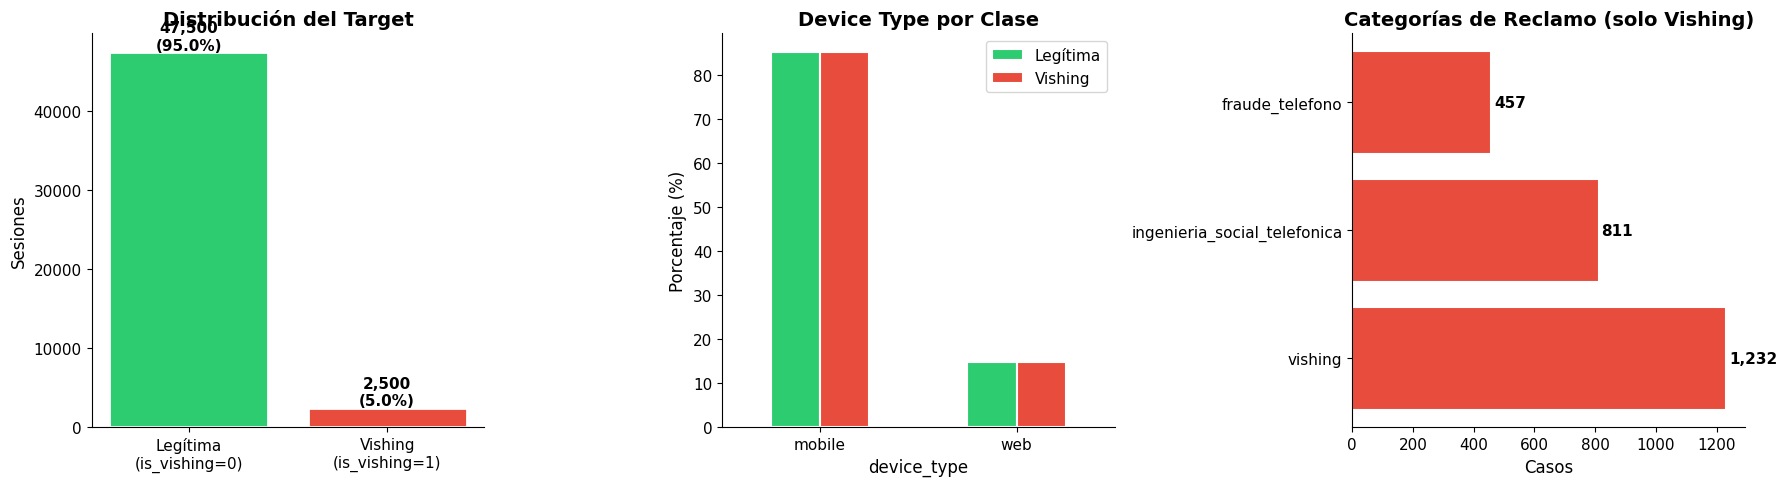

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 3.1 Target distribution
counts = df['is_vishing'].value_counts()
bars = axes[0].bar(['Legítima\n(is_vishing=0)', 'Vishing\n(is_vishing=1)'],
                    counts.values, color=[COLORS['legit'], COLORS['vishing']],
                    edgecolor='white', linewidth=2)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
                 f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title('Distribución del Target', fontweight='bold')
axes[0].set_ylabel('Sesiones')

# 3.2 Device type por label
ct = pd.crosstab(df['device_type'], df['is_vishing'], normalize='columns') * 100
ct.plot(kind='bar', ax=axes[1], color=[COLORS['legit'], COLORS['vishing']],
        edgecolor='white', linewidth=1.5)
axes[1].set_title('Device Type por Clase', fontweight='bold')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(['Legítima', 'Vishing'])

# 3.3 Claim category
claim_counts = df[df['is_vishing']==1]['claim_category'].value_counts()
axes[2].barh(claim_counts.index, claim_counts.values, color=COLORS['vishing'],
             edgecolor='white', linewidth=1.5)
for i, v in enumerate(claim_counts.values):
    axes[2].text(v + 10, i, f'{v:,}', va='center', fontweight='bold')
axes[2].set_title('Categorías de Reclamo (solo Vishing)', fontweight='bold')
axes[2].set_xlabel('Casos')

plt.tight_layout()
plt.show()

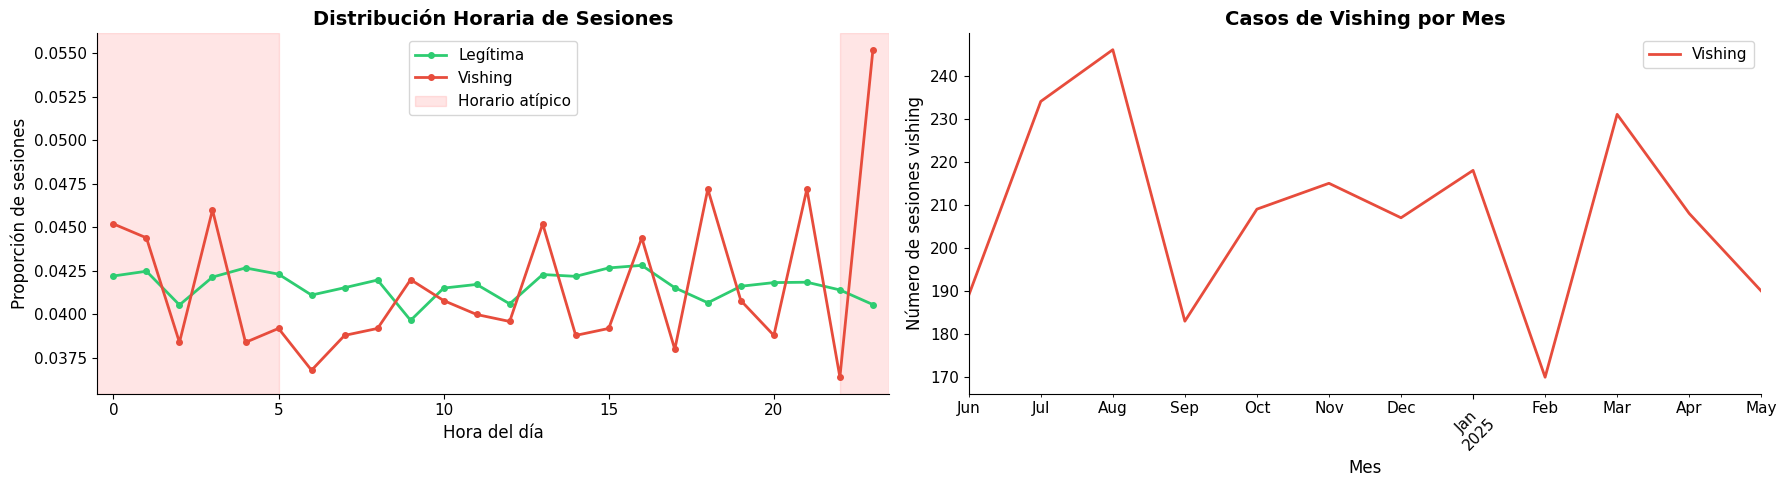

In [7]:
# 3.4 Distribución temporal
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Por hora del día
for label, subset, color in [(0, df_legit, COLORS['legit']), (1, df_vishing, COLORS['vishing'])]:
    hour_dist = subset['hour_of_day'].value_counts().sort_index()
    hour_dist = hour_dist / hour_dist.sum()  # normalizar
    axes[0].plot(hour_dist.index, hour_dist.values, '-o', color=color,
                 label=LABEL_MAP[label], linewidth=2, markersize=4)

axes[0].axvspan(22, 23.5, alpha=0.1, color='red', label='Horario atípico')
axes[0].axvspan(-0.5, 5, alpha=0.1, color='red')
axes[0].set_title('Distribución Horaria de Sesiones', fontweight='bold')
axes[0].set_xlabel('Hora del día')
axes[0].set_ylabel('Proporción de sesiones')
axes[0].legend()
axes[0].set_xlim(-0.5, 23.5)

# Por mes
df['month'] = df['session_timestamp'].dt.to_period('M')
monthly = df.groupby(['month', 'is_vishing']).size().unstack(fill_value=0)
monthly_pct = monthly.div(monthly.sum(axis=1), axis=0)
monthly[1].plot(ax=axes[1], color=COLORS['vishing'], linewidth=2, label='Vishing')
axes[1].set_title('Casos de Vishing por Mes', fontweight='bold')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Número de sesiones vishing')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()
df.drop(columns='month', inplace=True)

plt.tight_layout()
plt.show()

## 4. Análisis Univariado — Distribución de Features por Clase

Comparamos la distribución de cada feature entre sesiones legítimas y de vishing. 
Las diferencias en estas distribuciones son la señal que el modelo deberá aprender.

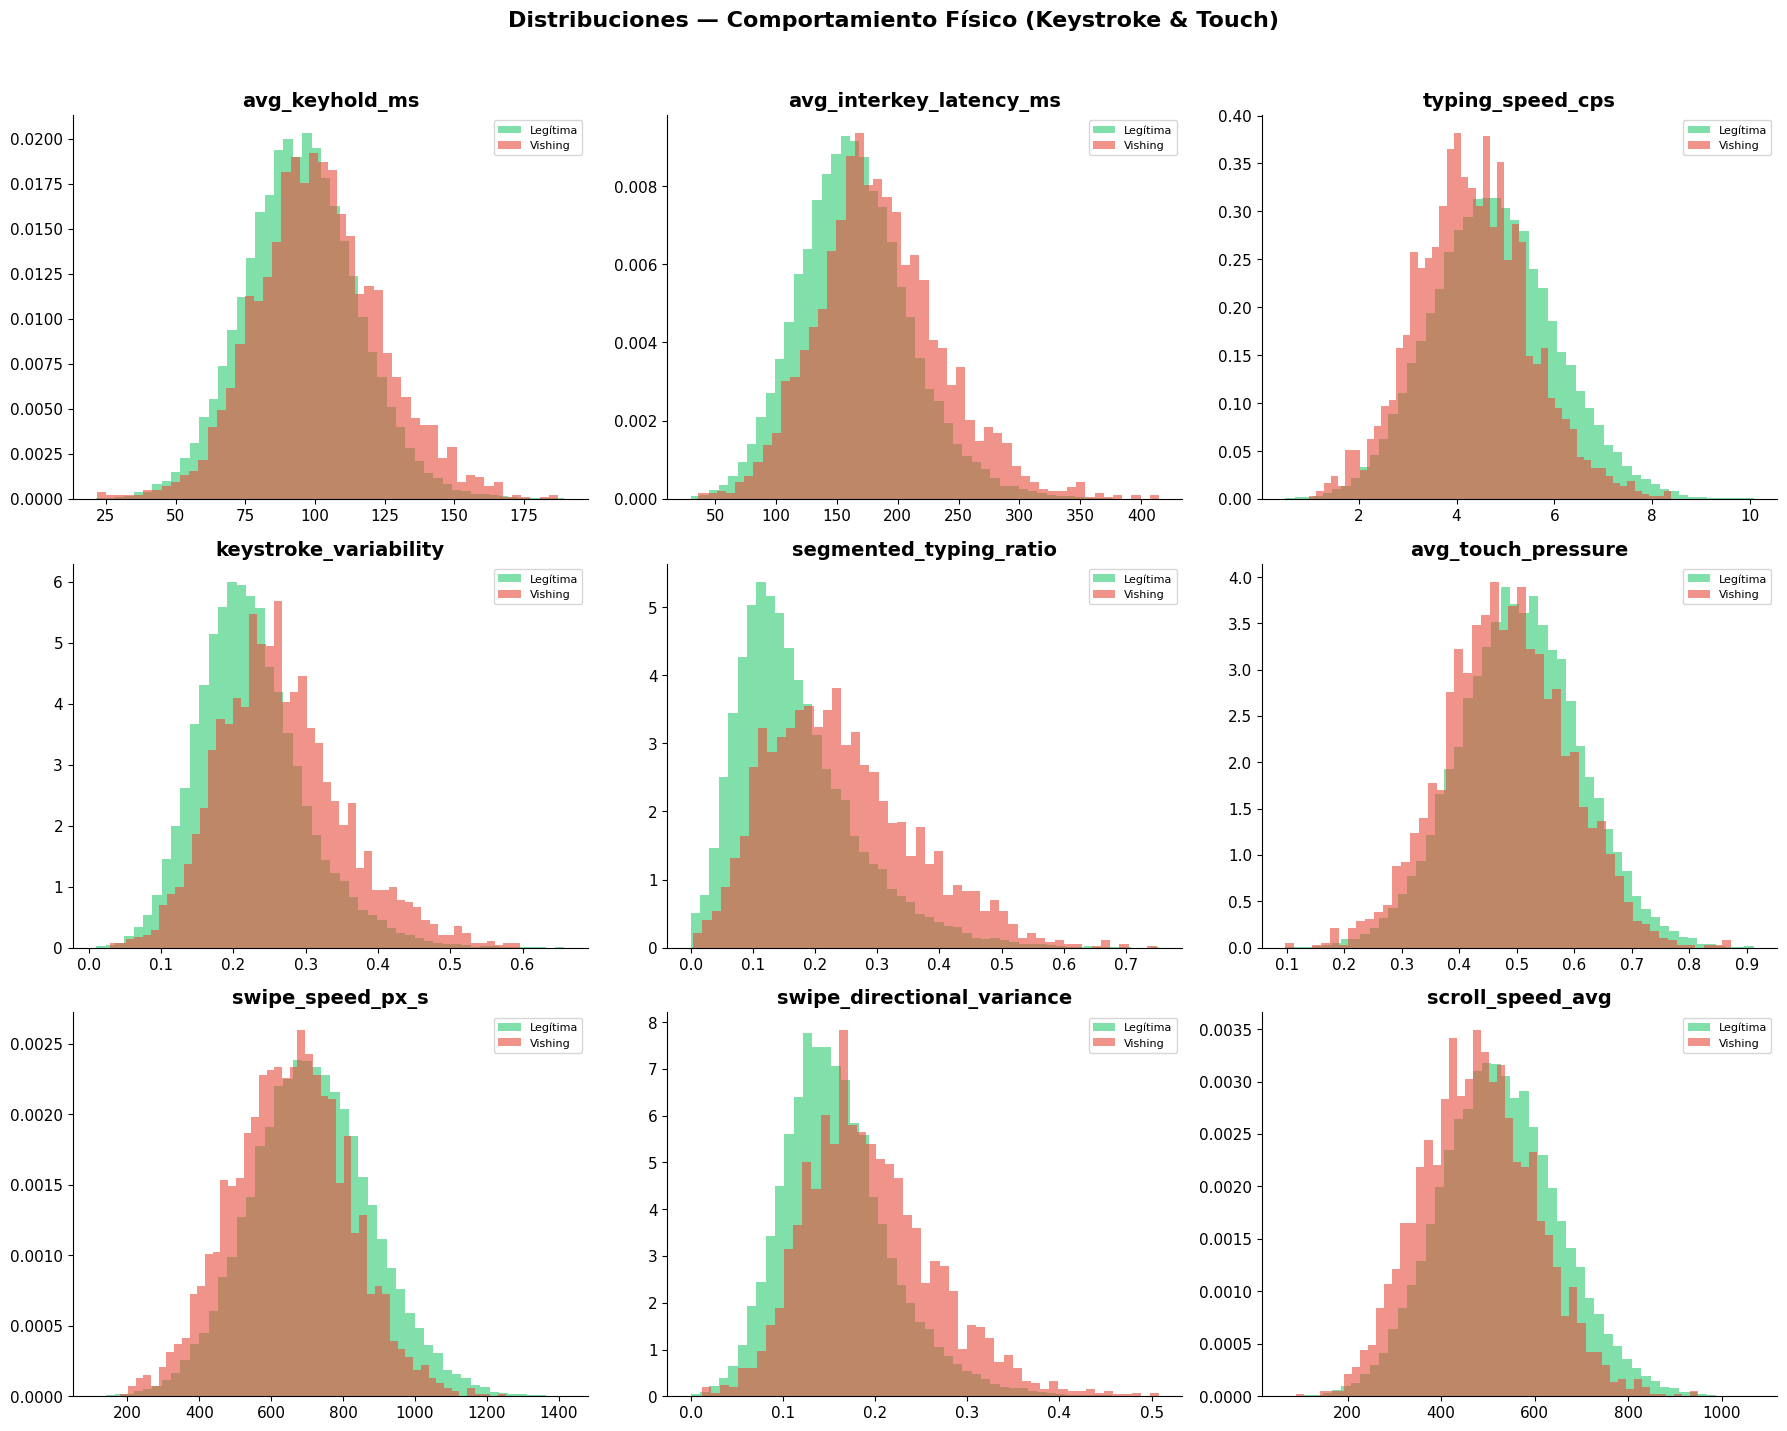

In [7]:
# 4.1 Features clave de comportamiento físico (keystroke + touch)
physical_features = [
    'avg_keyhold_ms', 'avg_interkey_latency_ms', 'typing_speed_cps',
    'keystroke_variability', 'segmented_typing_ratio', 'avg_touch_pressure',
    'swipe_speed_px_s', 'swipe_directional_variance', 'scroll_speed_avg'
]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.ravel()

for i, feat in enumerate(physical_features):
    ax = axes[i]
    ax.hist(df_legit[feat], bins=50, alpha=0.6, color=COLORS['legit'],
            label='Legítima', density=True, edgecolor='none')
    ax.hist(df_vishing[feat], bins=50, alpha=0.6, color=COLORS['vishing'],
            label='Vishing', density=True, edgecolor='none')
    ax.set_title(feat, fontweight='bold')
    ax.legend(fontsize=8)

fig.suptitle('Distribuciones — Comportamiento Físico (Keystroke & Touch)', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

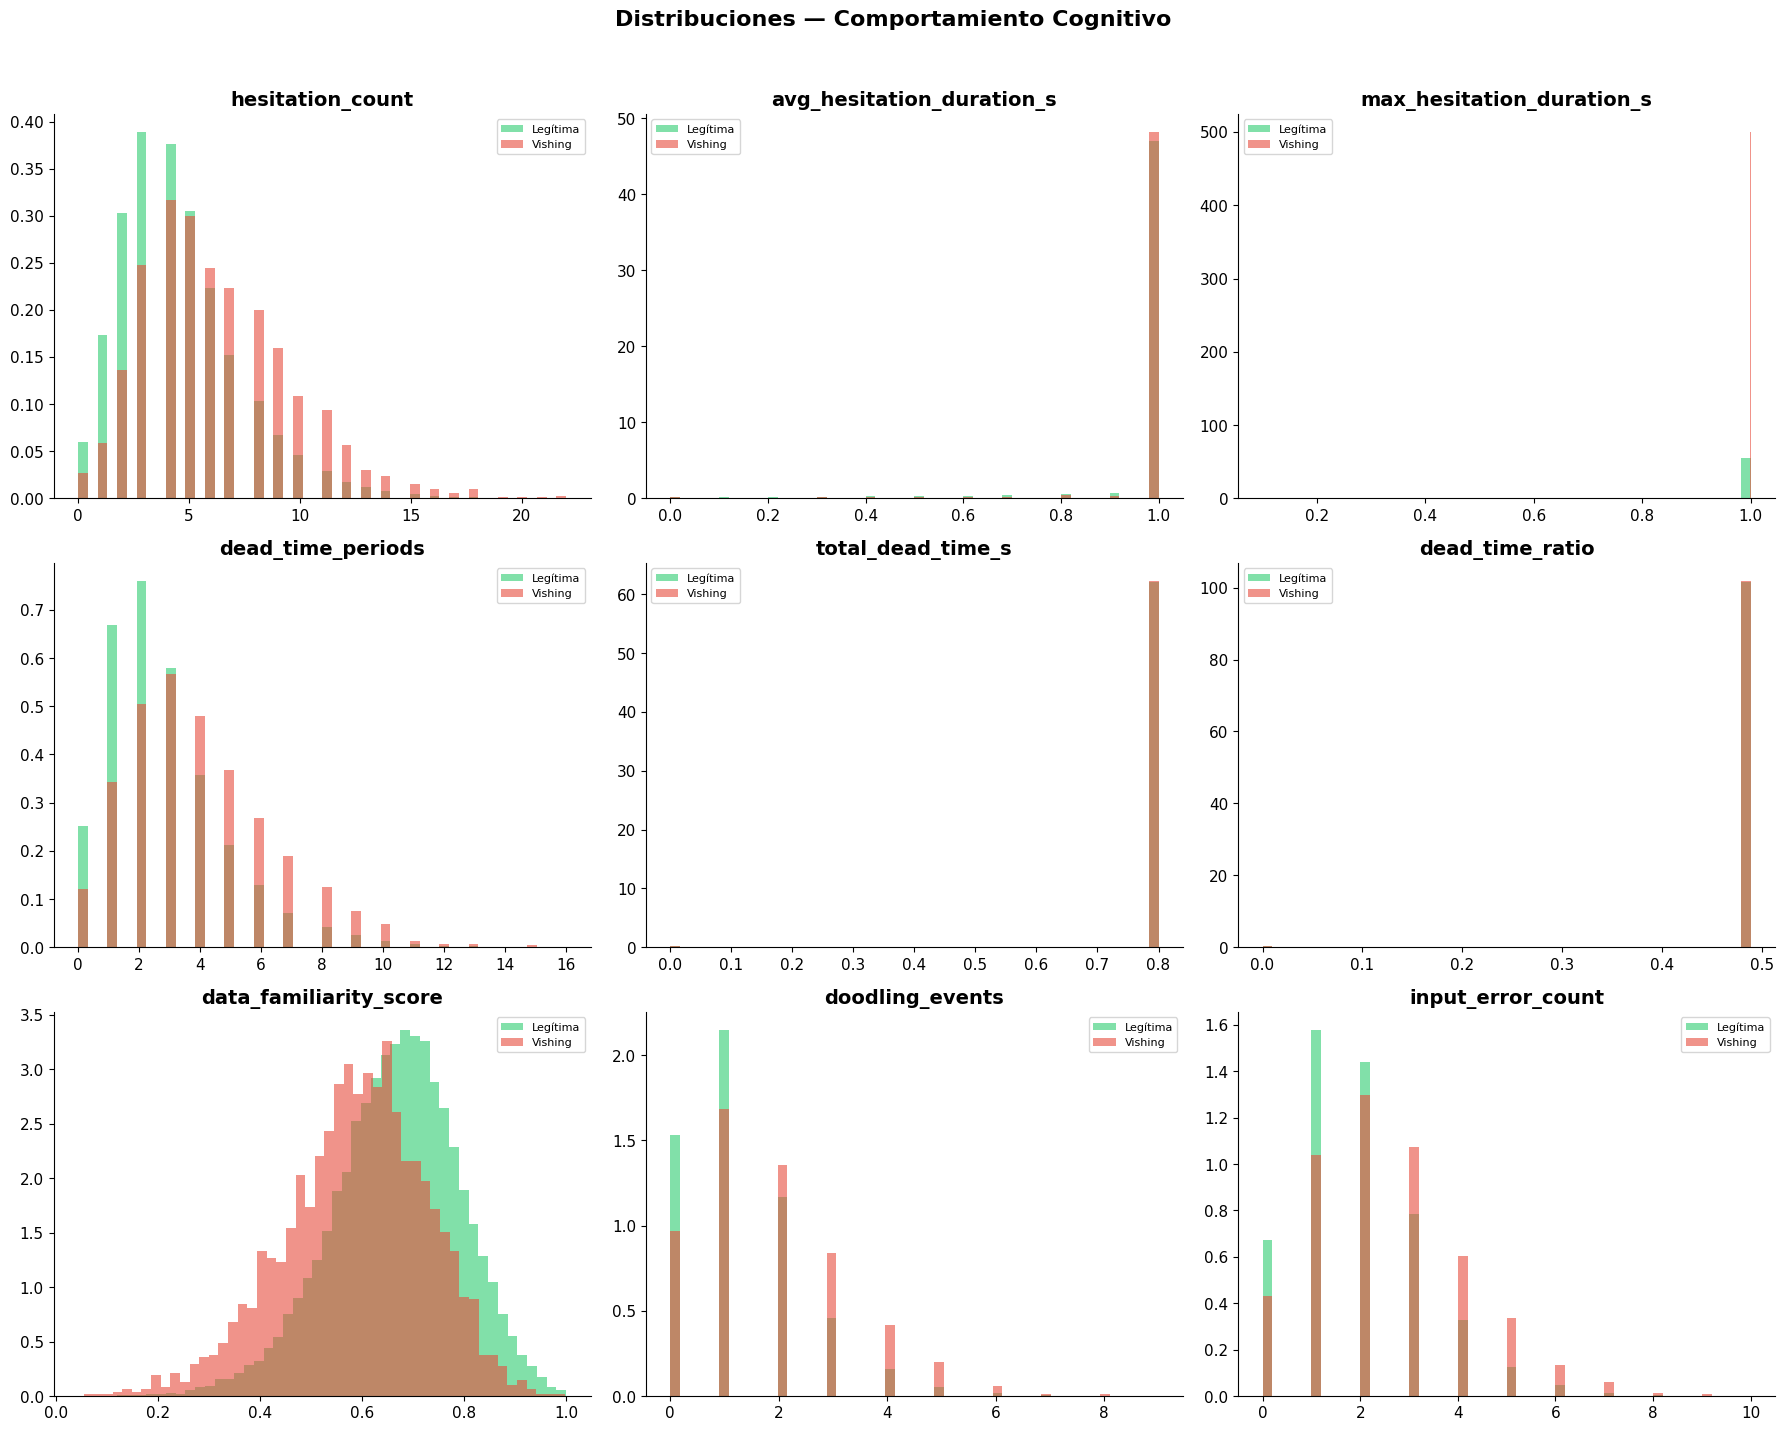

In [9]:
# 4.2 Features clave cognitivas
cognitive_features = [
    'hesitation_count', 'avg_hesitation_duration_s', 'max_hesitation_duration_s',
    'dead_time_periods', 'total_dead_time_s', 'dead_time_ratio',
    'data_familiarity_score', 'doodling_events', 'input_error_count'
]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.ravel()

for i, feat in enumerate(cognitive_features):
    ax = axes[i]
    ax.hist(df_legit[feat], bins=50, alpha=0.6, color=COLORS['legit'],
            label='Legítima', density=True, edgecolor='none')
    ax.hist(df_vishing[feat], bins=50, alpha=0.6, color=COLORS['vishing'],
            label='Vishing', density=True, edgecolor='none')
    ax.set_title(feat, fontweight='bold')
    ax.legend(fontsize=8)

fig.suptitle('Distribuciones — Comportamiento Cognitivo',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

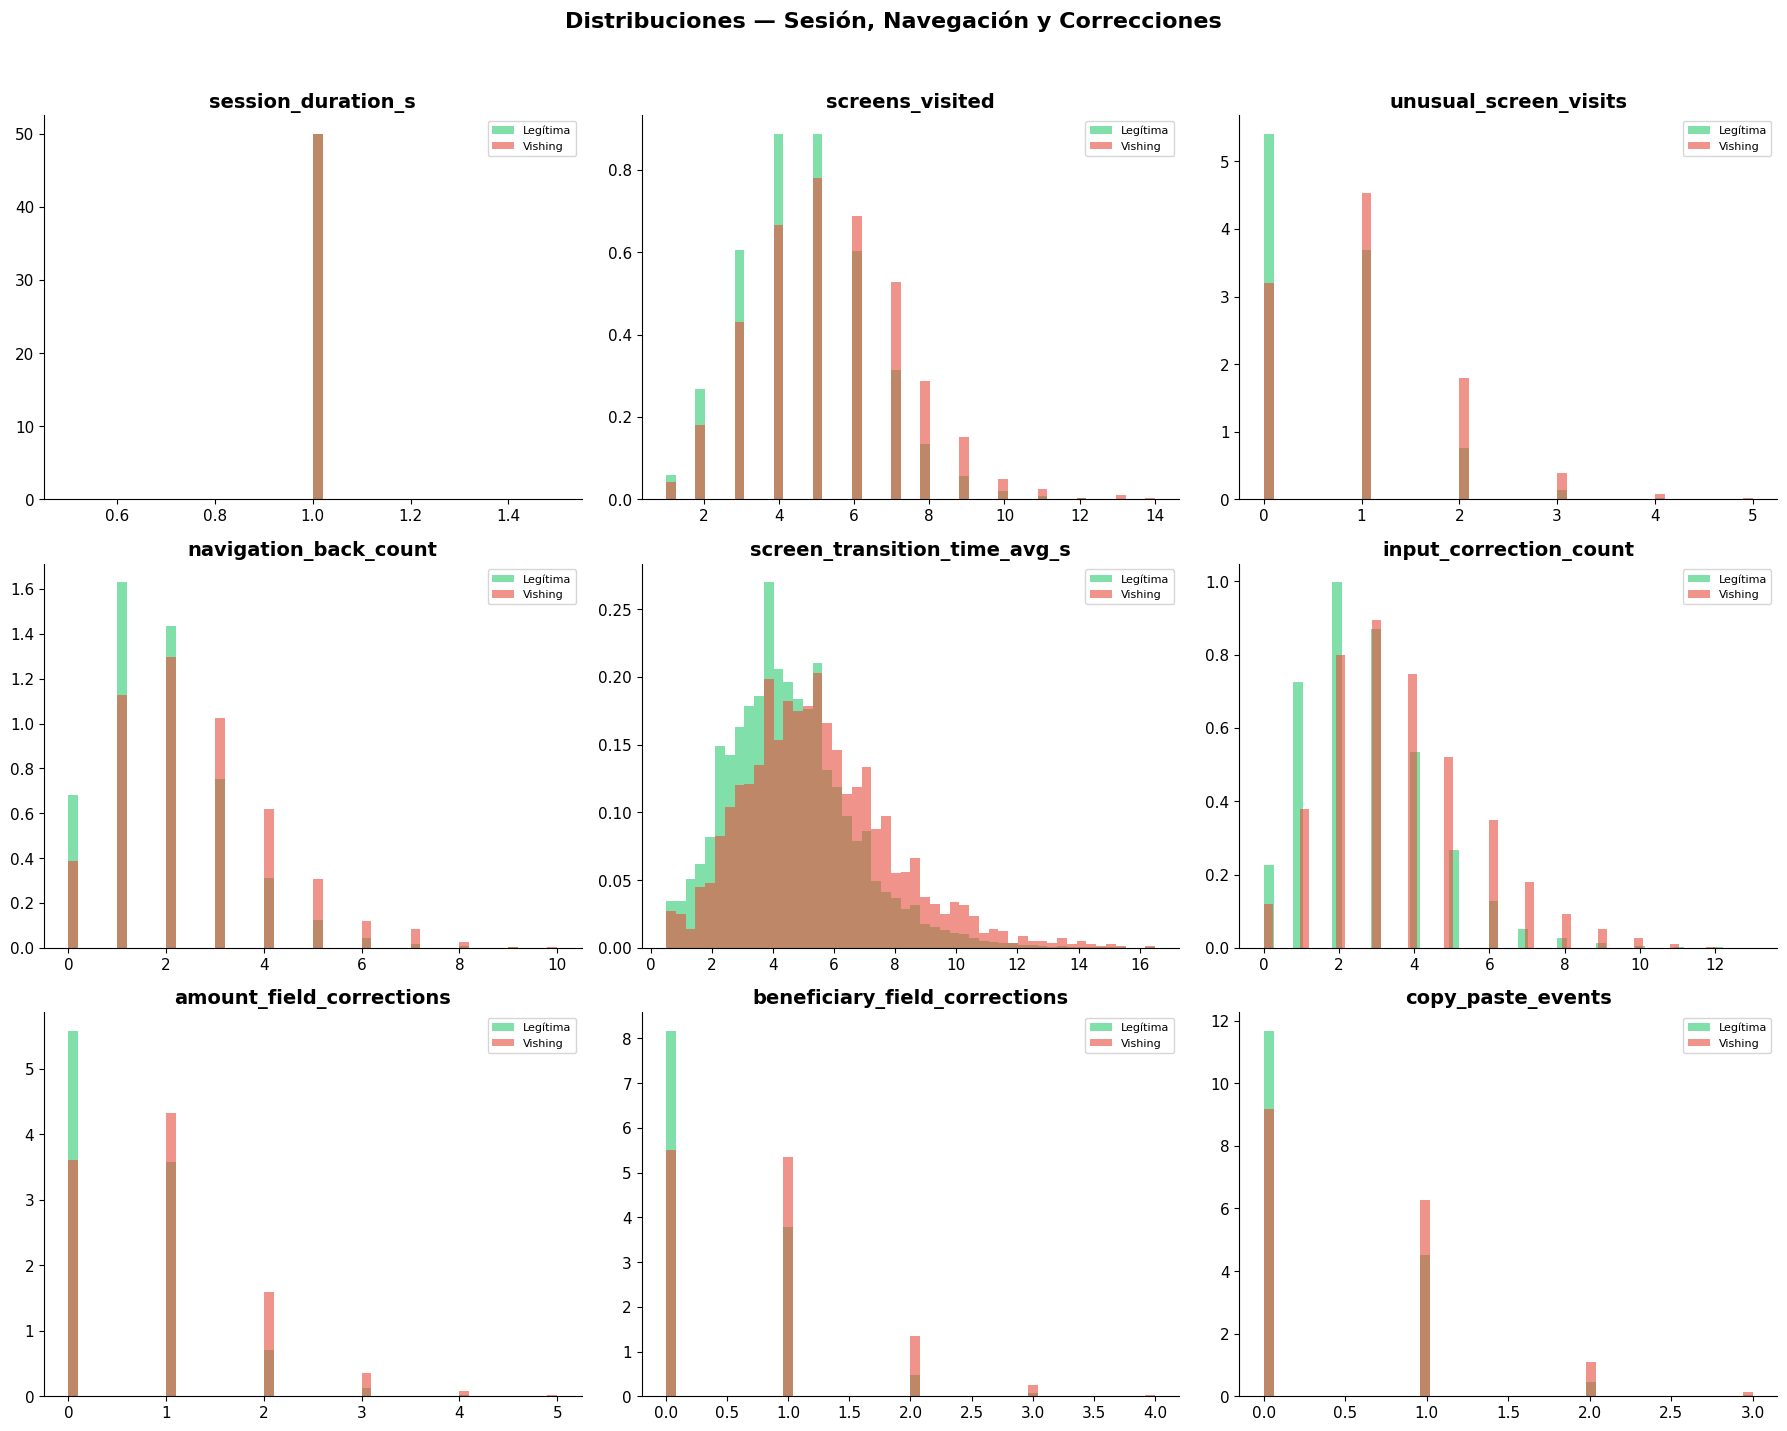

In [10]:
# 4.3 Features de sesión y contexto
session_features = [
    'session_duration_s', 'screens_visited', 'unusual_screen_visits',
    'navigation_back_count', 'screen_transition_time_avg_s',
    'input_correction_count', 'amount_field_corrections',
    'beneficiary_field_corrections', 'copy_paste_events'
]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.ravel()

for i, feat in enumerate(session_features):
    ax = axes[i]
    ax.hist(df_legit[feat], bins=50, alpha=0.6, color=COLORS['legit'],
            label='Legítima', density=True, edgecolor='none')
    ax.hist(df_vishing[feat], bins=50, alpha=0.6, color=COLORS['vishing'],
            label='Vishing', density=True, edgecolor='none')
    ax.set_title(feat, fontweight='bold')
    ax.legend(fontsize=8)

fig.suptitle('Distribuciones — Sesión, Navegación y Correcciones',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5. Tests Estadísticos de Separabilidad

Para cada feature numérica calculamos:
- **Mann-Whitney U test**: test no paramétrico para diferencia de distribuciones (no asume normalidad)
- **Effect size (Cohen's d)**: magnitud práctica de la diferencia
- **Point-biserial correlation**: correlación con el target binario
- **AUC univariada**: capacidad de discriminación individual de cada feature


In [11]:
from sklearn.metrics import roc_auc_score

# Features a evaluar (excluir IDs, timestamps, labels, scores BioCatch)
exclude = ['is_vishing', 'days_to_claim', 'biocatch_risk_score', 'biocatch_genuine_score',
           'biocatch_ato_indicator', 'biocatch_social_eng_indicator', 'biocatch_bot_indicator']
features_to_test = [c for c in numeric_cols if c not in exclude]

results = []
for feat in features_to_test:
    x0 = df_legit[feat].dropna()
    x1 = df_vishing[feat].dropna()
    
    # Mann-Whitney U
    u_stat, p_val = mannwhitneyu(x0, x1, alternative='two-sided')
    
    # Cohen's d
    pooled_std = np.sqrt((x0.std()**2 + x1.std()**2) / 2)
    cohens_d = (x1.mean() - x0.mean()) / pooled_std if pooled_std > 0 else 0
    
    # Point-biserial correlation
    r_pb, p_pb = pointbiserialr(df['is_vishing'], df[feat])
    
    # AUC univariada
    try:
        auc = roc_auc_score(df['is_vishing'], df[feat])
        auc = max(auc, 1 - auc)  # asegurar > 0.5
    except:
        auc = 0.5
    
    results.append({
        'feature': feat,
        'mean_legit': x0.mean(),
        'mean_vishing': x1.mean(),
        'pct_change': ((x1.mean() - x0.mean()) / x0.mean() * 100) if x0.mean() != 0 else np.inf,
        'cohens_d': cohens_d,
        'abs_cohens_d': abs(cohens_d),
        'mann_whitney_p': p_val,
        'point_biserial_r': r_pb,
        'auc_univariate': auc,
    })

df_stats = pd.DataFrame(results).sort_values('abs_cohens_d', ascending=False)

# Clasificar effect size
def classify_effect(d):
    d = abs(d)
    if d >= 1.2: return '🔴 Muy grande'
    elif d >= 0.8: return '🟠 Grande'
    elif d >= 0.5: return '🟡 Mediano'
    elif d >= 0.2: return '🔵 Pequeño'
    else: return '⚪ Negligible'

df_stats['effect_size'] = df_stats['cohens_d'].apply(classify_effect)
df_stats['significant'] = df_stats['mann_whitney_p'] < 0.001

print(f'Features evaluadas: {len(df_stats)}')
print(f'\nDistribución de effect sizes:')
print(df_stats['effect_size'].value_counts().to_string())
print(f'\nSignificativas (p < 0.001): {df_stats["significant"].sum()} de {len(df_stats)}')

Features evaluadas: 47

Distribución de effect sizes:
effect_size
🔵 Pequeño       23
⚪ Negligible    16
🟡 Mediano        8

Significativas (p < 0.001): 38 de 47


In [12]:
# Tabla completa de resultados — Top 30 features por |Cohen's d|
display_cols = ['feature', 'mean_legit', 'mean_vishing', 'pct_change',
                'cohens_d', 'effect_size', 'auc_univariate', 'point_biserial_r']

styled = (df_stats[display_cols].head(30)
          .style
          .format({
              'mean_legit': '{:.3f}',
              'mean_vishing': '{:.3f}',
              'pct_change': '{:+.1f}%',
              'cohens_d': '{:+.3f}',
              'auc_univariate': '{:.4f}',
              'point_biserial_r': '{:+.4f}',
          })
          .bar(subset=['auc_univariate'], color='#3498db', vmin=0.5, vmax=1.0)
)
styled

,feature,mean_legit,mean_vishing,pct_change,cohens_d,effect_size,auc_univariate,point_biserial_r
4,segmented_typing_ratio,0.169,0.241,+42.2%,+0.667,🟡 Mediano,0.6890,+0.1585
31,data_familiarity_score,0.665,0.588,-11.7%,-0.586,🟡 Mediano,0.6609,-0.1333
15,hesitation_count,4.500,6.260,+39.1%,+0.574,🟡 Mediano,0.6614,+0.1372
8,swipe_directional_variance,0.159,0.195,+22.6%,+0.547,🟡 Mediano,0.6540,+0.1285
18,dead_time_periods,2.739,3.948,+44.1%,+0.537,🟡 Mediano,0.6533,+0.1274
27,input_correction_count,2.691,3.642,+35.3%,+0.515,🟡 Mediano,0.6422,+0.1213
3,keystroke_variability,0.225,0.266,+18.4%,+0.510,🟡 Mediano,0.6450,+0.1187
23,unusual_screen_visits,0.567,0.965,+70.1%,+0.505,🟡 Mediano,0.6325,+0.1200
29,beneficiary_field_corrections,0.396,0.714,+80.6%,+0.469,🔵 Pequeño,0.6168,+0.1148
14,phone_motion_events,12.697,15.602,+22.9%,+0.468,🔵 Pequeño,0.6299,+0.1111


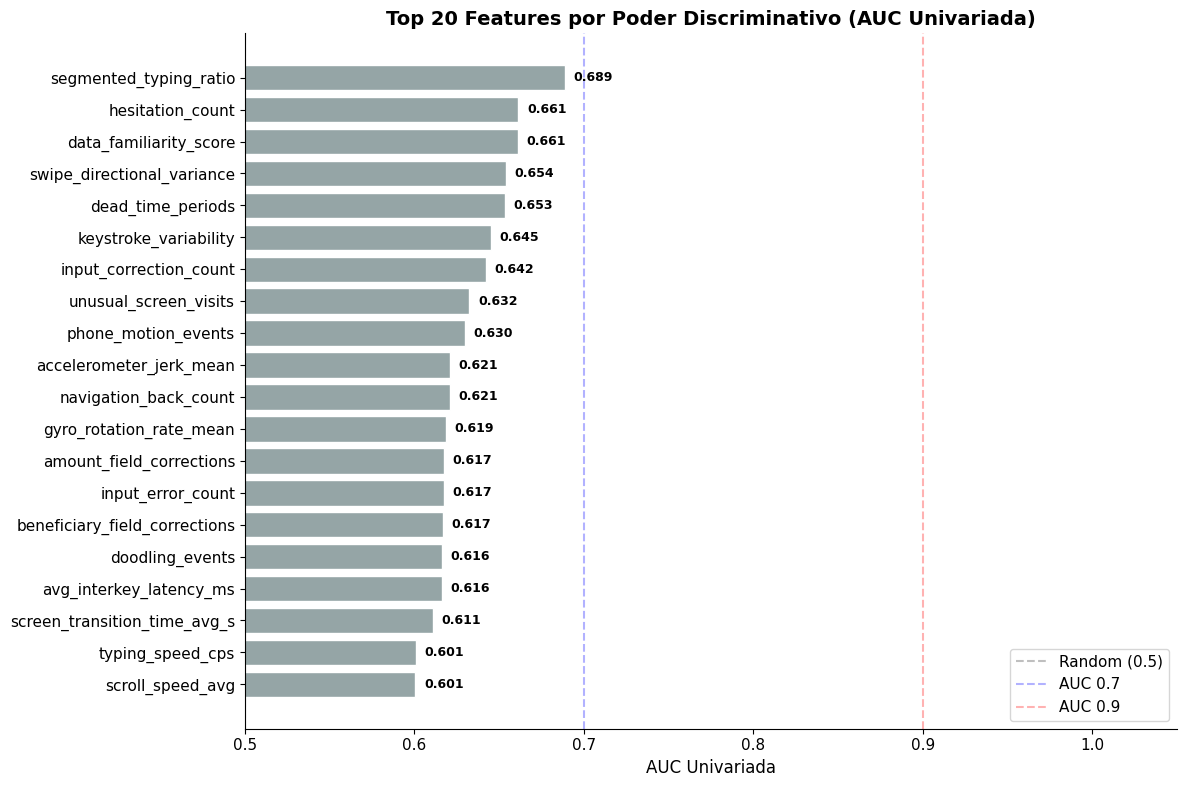

In [13]:
# 5.2 Visualización: Top 20 features por AUC univariada
top20 = df_stats.nlargest(20, 'auc_univariate')

fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#e74c3c' if x >= 0.9 else '#f39c12' if x >= 0.8 else '#3498db' if x >= 0.7 else '#95a5a6'
          for x in top20['auc_univariate']]

bars = ax.barh(range(len(top20)), top20['auc_univariate'].values, color=colors,
               edgecolor='white', linewidth=1)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20['feature'].values)
ax.set_xlabel('AUC Univariada')
ax.set_title('Top 20 Features por Poder Discriminativo (AUC Univariada)', fontweight='bold')
ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Random (0.5)')
ax.axvline(x=0.7, color='blue', linestyle='--', alpha=0.3, label='AUC 0.7')
ax.axvline(x=0.9, color='red', linestyle='--', alpha=0.3, label='AUC 0.9')

for bar, val in zip(bars, top20['auc_univariate'].values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
            va='center', fontsize=9, fontweight='bold')

ax.legend(loc='lower right')
ax.set_xlim(0.5, 1.05)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

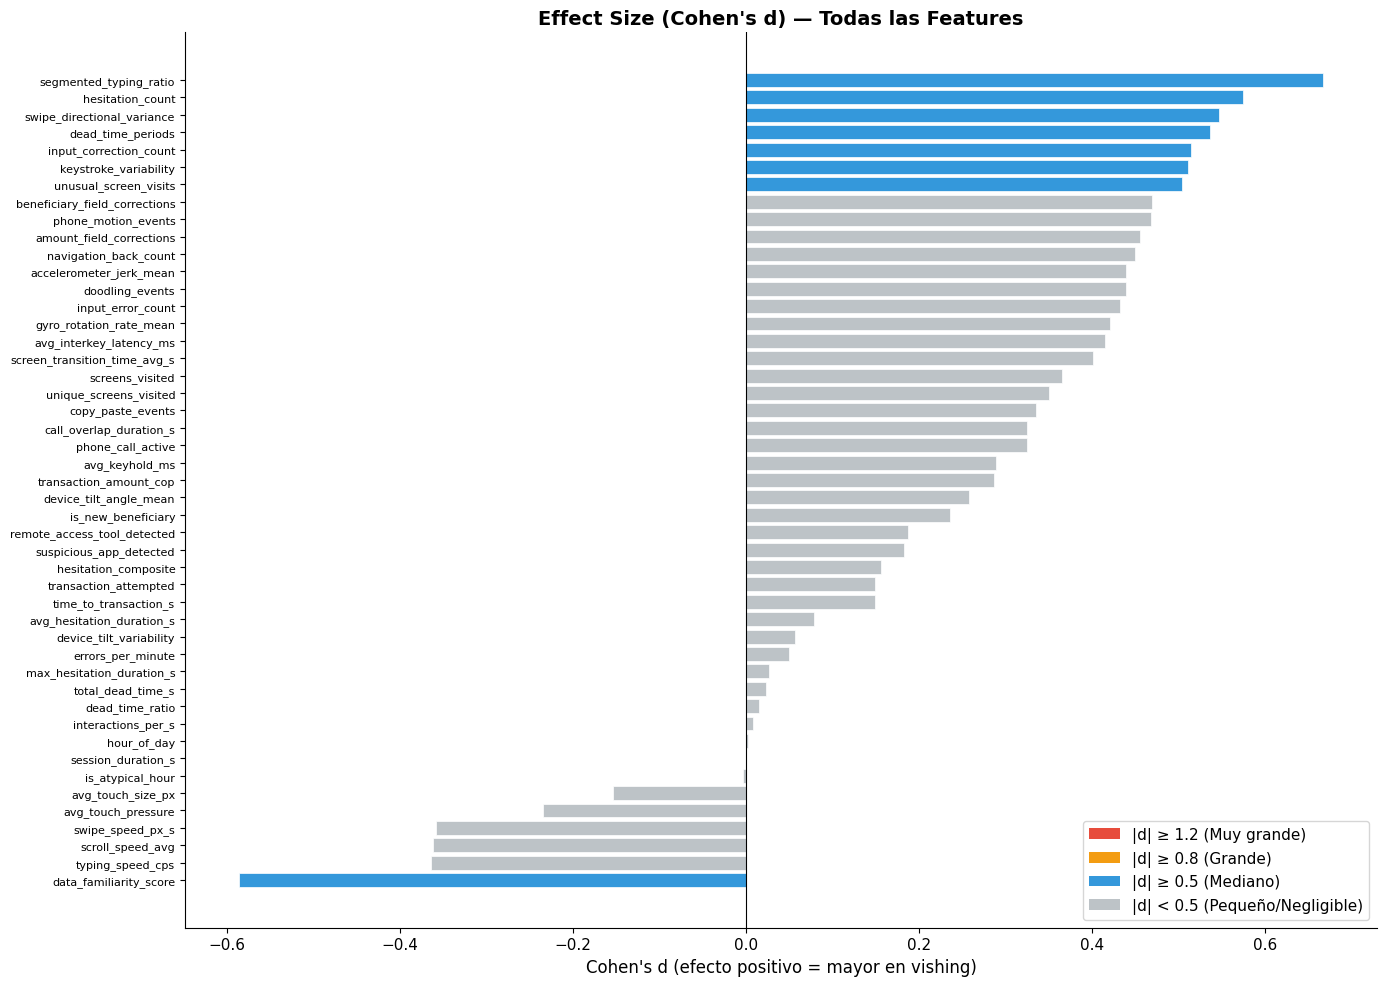

In [14]:
# 5.3 Cohen's d — todas las features
fig, ax = plt.subplots(figsize=(14, 10))

df_sorted = df_stats.sort_values('cohens_d')
colors_d = ['#e74c3c' if abs(d) >= 1.2 else '#f39c12' if abs(d) >= 0.8 
            else '#3498db' if abs(d) >= 0.5 else '#bdc3c7' for d in df_sorted['cohens_d']]

ax.barh(range(len(df_sorted)), df_sorted['cohens_d'].values, color=colors_d,
        edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(df_sorted)))
ax.set_yticklabels(df_sorted['feature'].values, fontsize=8)
ax.set_xlabel("Cohen's d (efecto positivo = mayor en vishing)")
ax.set_title("Effect Size (Cohen's d) — Todas las Features", fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8)

# Leyenda manual
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='|d| ≥ 1.2 (Muy grande)'),
    Patch(facecolor='#f39c12', label='|d| ≥ 0.8 (Grande)'),
    Patch(facecolor='#3498db', label='|d| ≥ 0.5 (Mediano)'),
    Patch(facecolor='#bdc3c7', label='|d| < 0.5 (Pequeño/Negligible)'),
]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

## 6. Análisis de Variables Binarias y Categóricas

Para las variables binarias (phone_call_active, is_new_beneficiary, etc.) 
usamos chi-cuadrado y odds ratio.

In [15]:
binary_features = ['phone_call_active', 'is_atypical_hour', 'transaction_attempted',
                   'is_new_beneficiary', 'remote_access_tool_detected', 'suspicious_app_detected']

binary_results = []
for feat in binary_features:
    ct = pd.crosstab(df[feat], df['is_vishing'])
    chi2, p, dof, expected = chi2_contingency(ct)
    
    # Odds ratio
    a, b = ct.iloc[1, 1], ct.iloc[1, 0]  # vishing=1 & feat=1, legit & feat=1
    c, d_ = ct.iloc[0, 1], ct.iloc[0, 0]  # vishing=1 & feat=0, legit & feat=0
    odds_ratio = (a * d_) / (b * c) if (b * c) > 0 else np.inf
    
    pct_legit = df_legit[feat].mean() * 100
    pct_vishing = df_vishing[feat].mean() * 100
    
    binary_results.append({
        'feature': feat,
        'pct_legit': pct_legit,
        'pct_vishing': pct_vishing,
        'chi2': chi2,
        'p_value': p,
        'odds_ratio': odds_ratio,
    })

df_binary = pd.DataFrame(binary_results).sort_values('odds_ratio', ascending=False)

print('ANÁLISIS DE VARIABLES BINARIAS (Chi-cuadrado + Odds Ratio)')
print('='*80)
for _, row in df_binary.iterrows():
    sig = '***' if row['p_value'] < 0.001 else '**' if row['p_value'] < 0.01 else 'ns'
    print(f"\n  {row['feature']}:")
    print(f"    Legítima: {row['pct_legit']:.1f}%  |  Vishing: {row['pct_vishing']:.1f}%")
    print(f"    Odds Ratio: {row['odds_ratio']:.2f}x  |  χ²={row['chi2']:.1f}  |  {sig}")

ANÁLISIS DE VARIABLES BINARIAS (Chi-cuadrado + Odds Ratio)

  remote_access_tool_detected:
    Legítima: 2.7%  |  Vishing: 6.6%
    Odds Ratio: 2.57x  |  χ²=130.2  |  ***

  suspicious_app_detected:
    Legítima: 5.1%  |  Vishing: 9.9%
    Odds Ratio: 2.05x  |  χ²=107.3  |  ***

  phone_call_active:
    Legítima: 24.4%  |  Vishing: 39.3%
    Odds Ratio: 2.01x  |  χ²=281.9  |  ***

  is_new_beneficiary:
    Legítima: 17.7%  |  Vishing: 27.4%
    Odds Ratio: 1.76x  |  χ²=152.5  |  ***

  transaction_attempted:
    Legítima: 55.6%  |  Vishing: 62.9%
    Odds Ratio: 1.35x  |  χ²=51.2  |  ***

  is_atypical_hour:
    Legítima: 34.0%  |  Vishing: 33.8%
    Odds Ratio: 0.99x  |  χ²=0.0  |  ns


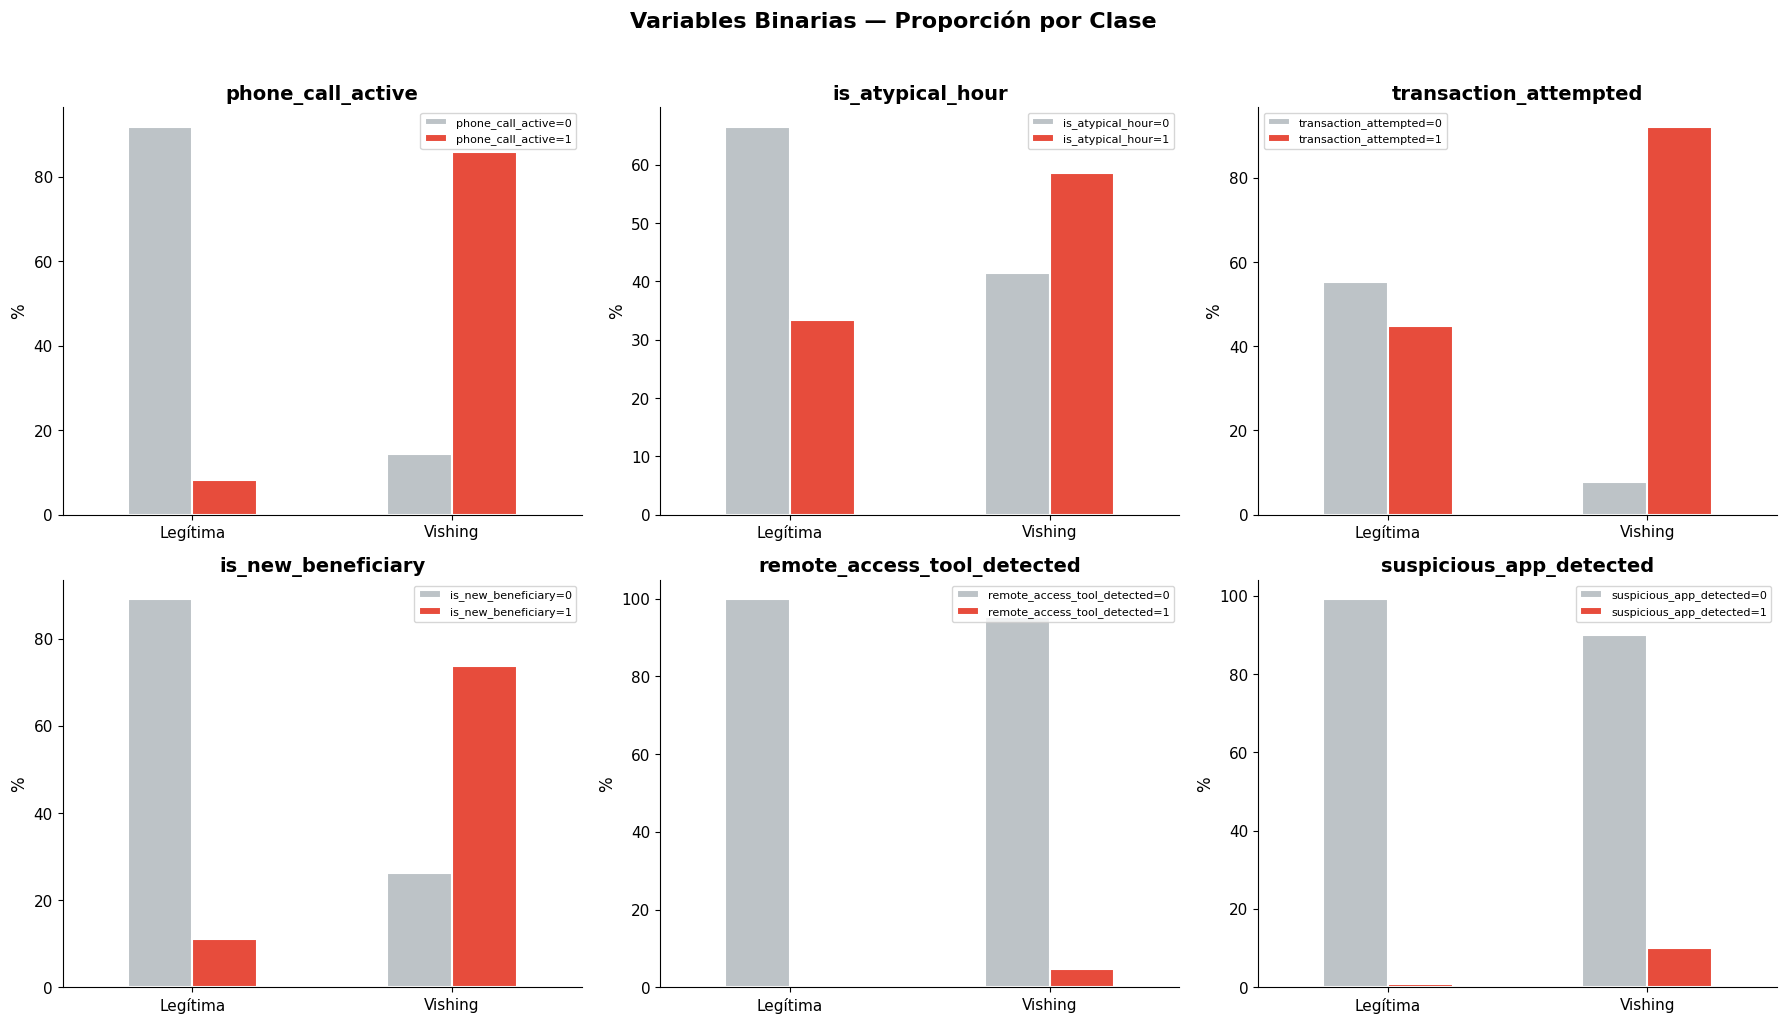

In [19]:
# Visualización de variables binarias
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for i, feat in enumerate(binary_features):
    ax = axes[i]
    ct = pd.crosstab(df['is_vishing'], df[feat], normalize='index') * 100
    ct.index = ['Legítima', 'Vishing']
    ct.columns = [f'{feat}=0', f'{feat}=1']
    ct.plot(kind='bar', ax=ax, color=['#bdc3c7', COLORS['vishing']],
            edgecolor='white', linewidth=1.5)
    ax.set_title(feat, fontweight='bold')
    ax.set_ylabel('%')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(fontsize=8)

plt.suptitle('Variables Binarias — Proporción por Clase', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. Boxplots Comparativos — Top Features

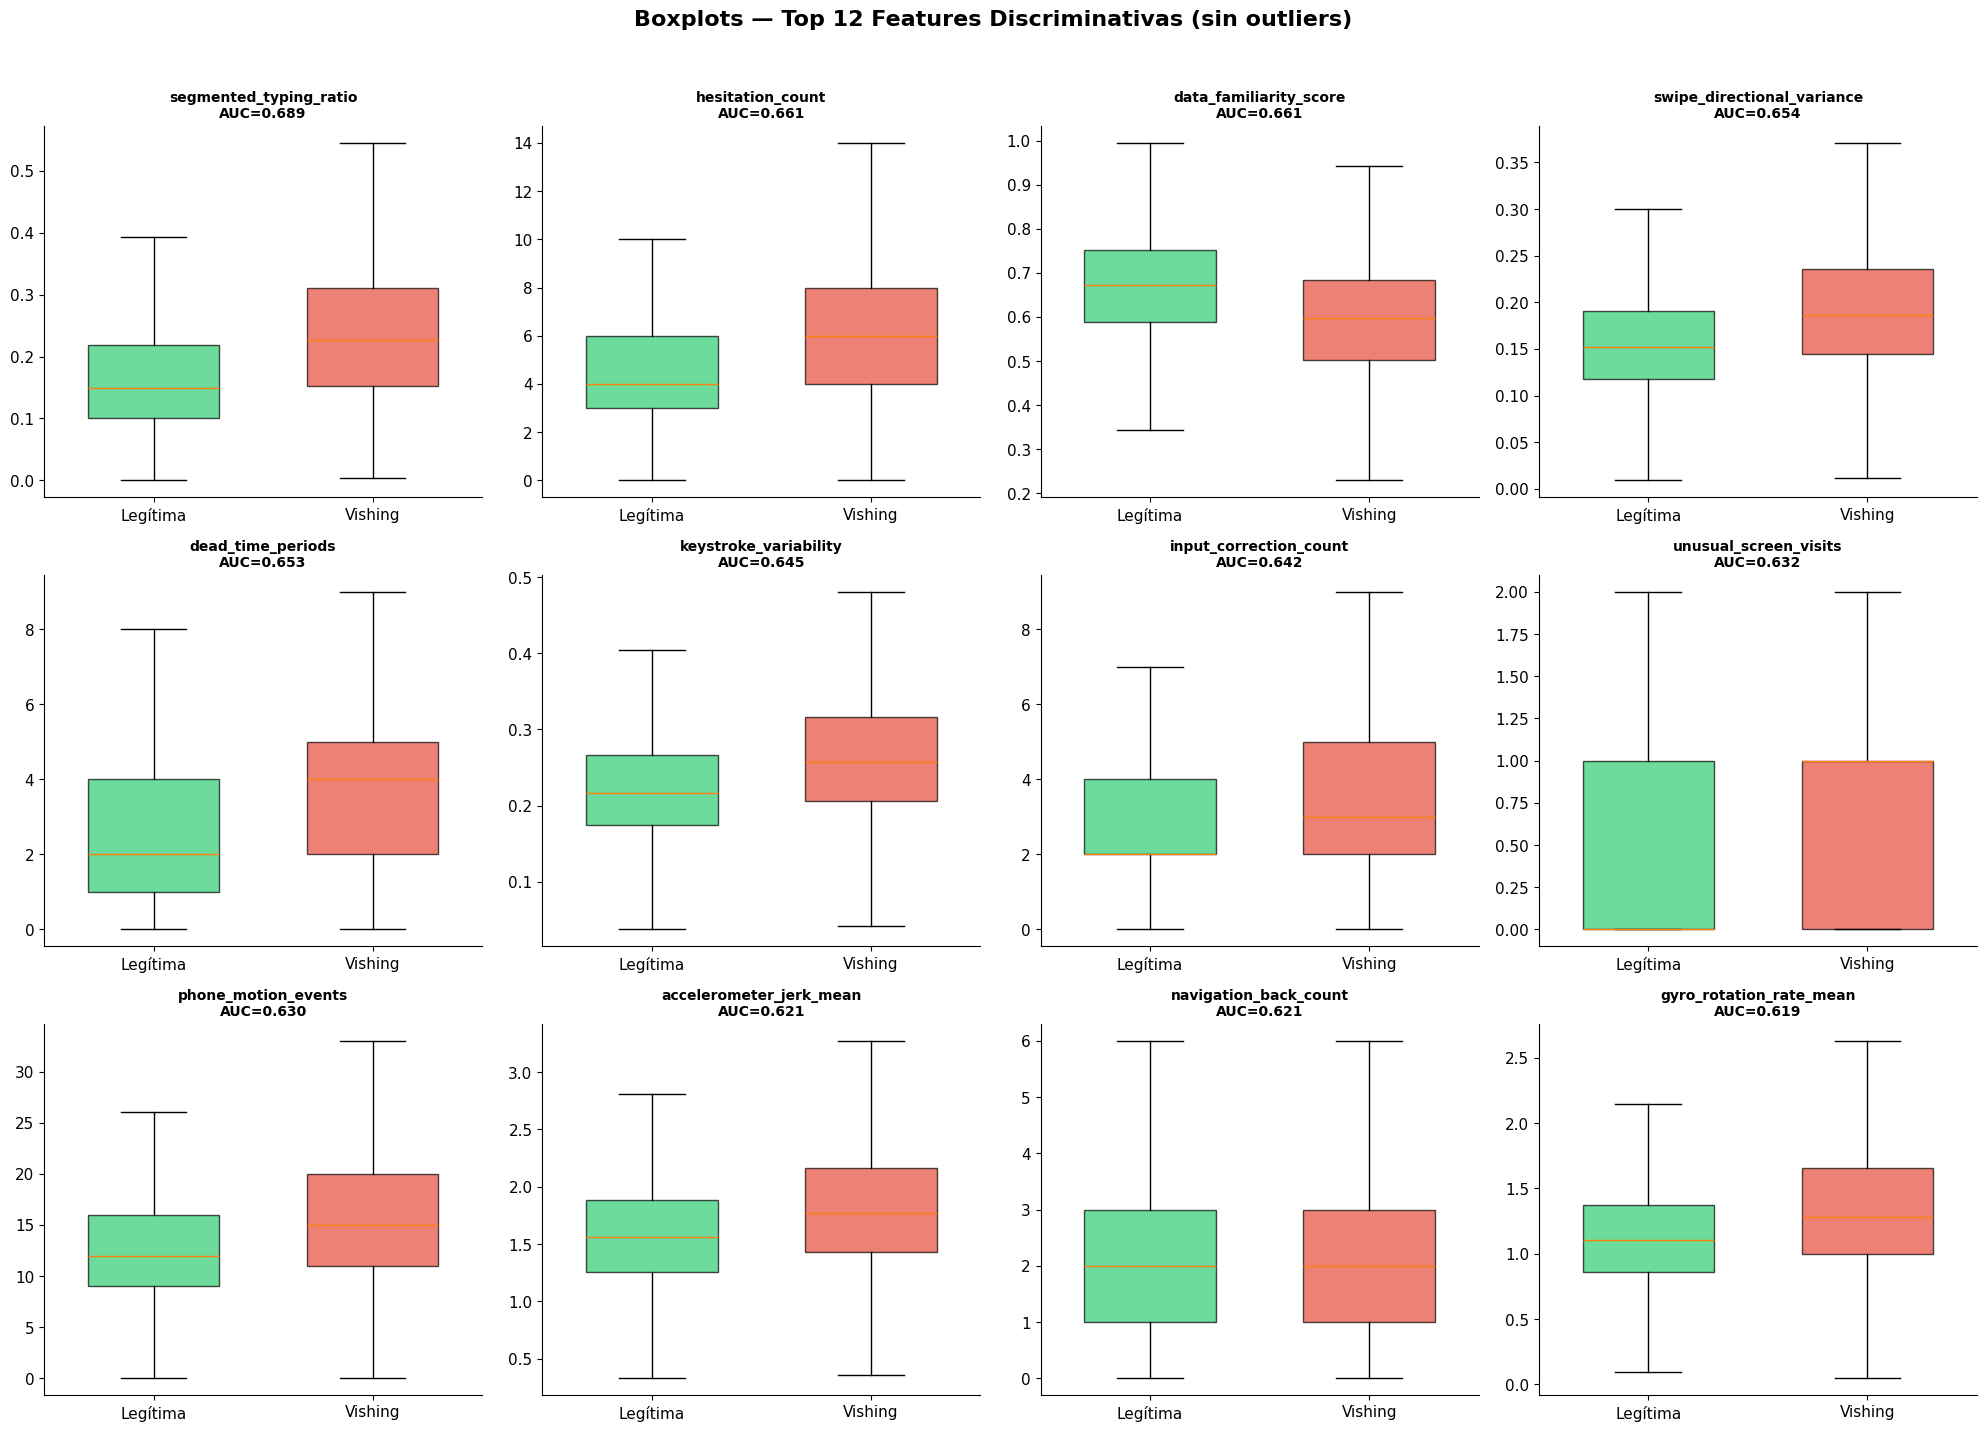

In [16]:
# Top 12 features por AUC
top12 = df_stats.nlargest(12, 'auc_univariate')['feature'].tolist()

fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.ravel()

for i, feat in enumerate(top12):
    ax = axes[i]
    data_to_plot = [df_legit[feat].values, df_vishing[feat].values]
    bp = ax.boxplot(data_to_plot, labels=['Legítima', 'Vishing'], patch_artist=True,
                    widths=0.6, showfliers=False)
    bp['boxes'][0].set_facecolor(COLORS['legit'])
    bp['boxes'][1].set_facecolor(COLORS['vishing'])
    for box in bp['boxes']:
        box.set_alpha(0.7)
    
    auc_val = df_stats[df_stats['feature']==feat]['auc_univariate'].values[0]
    ax.set_title(f'{feat}\nAUC={auc_val:.3f}', fontweight='bold', fontsize=10)

plt.suptitle('Boxplots — Top 12 Features Discriminativas (sin outliers)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 8. Análisis de Correlaciones

Examinamos correlaciones entre features para identificar redundancias y clusters de variables.

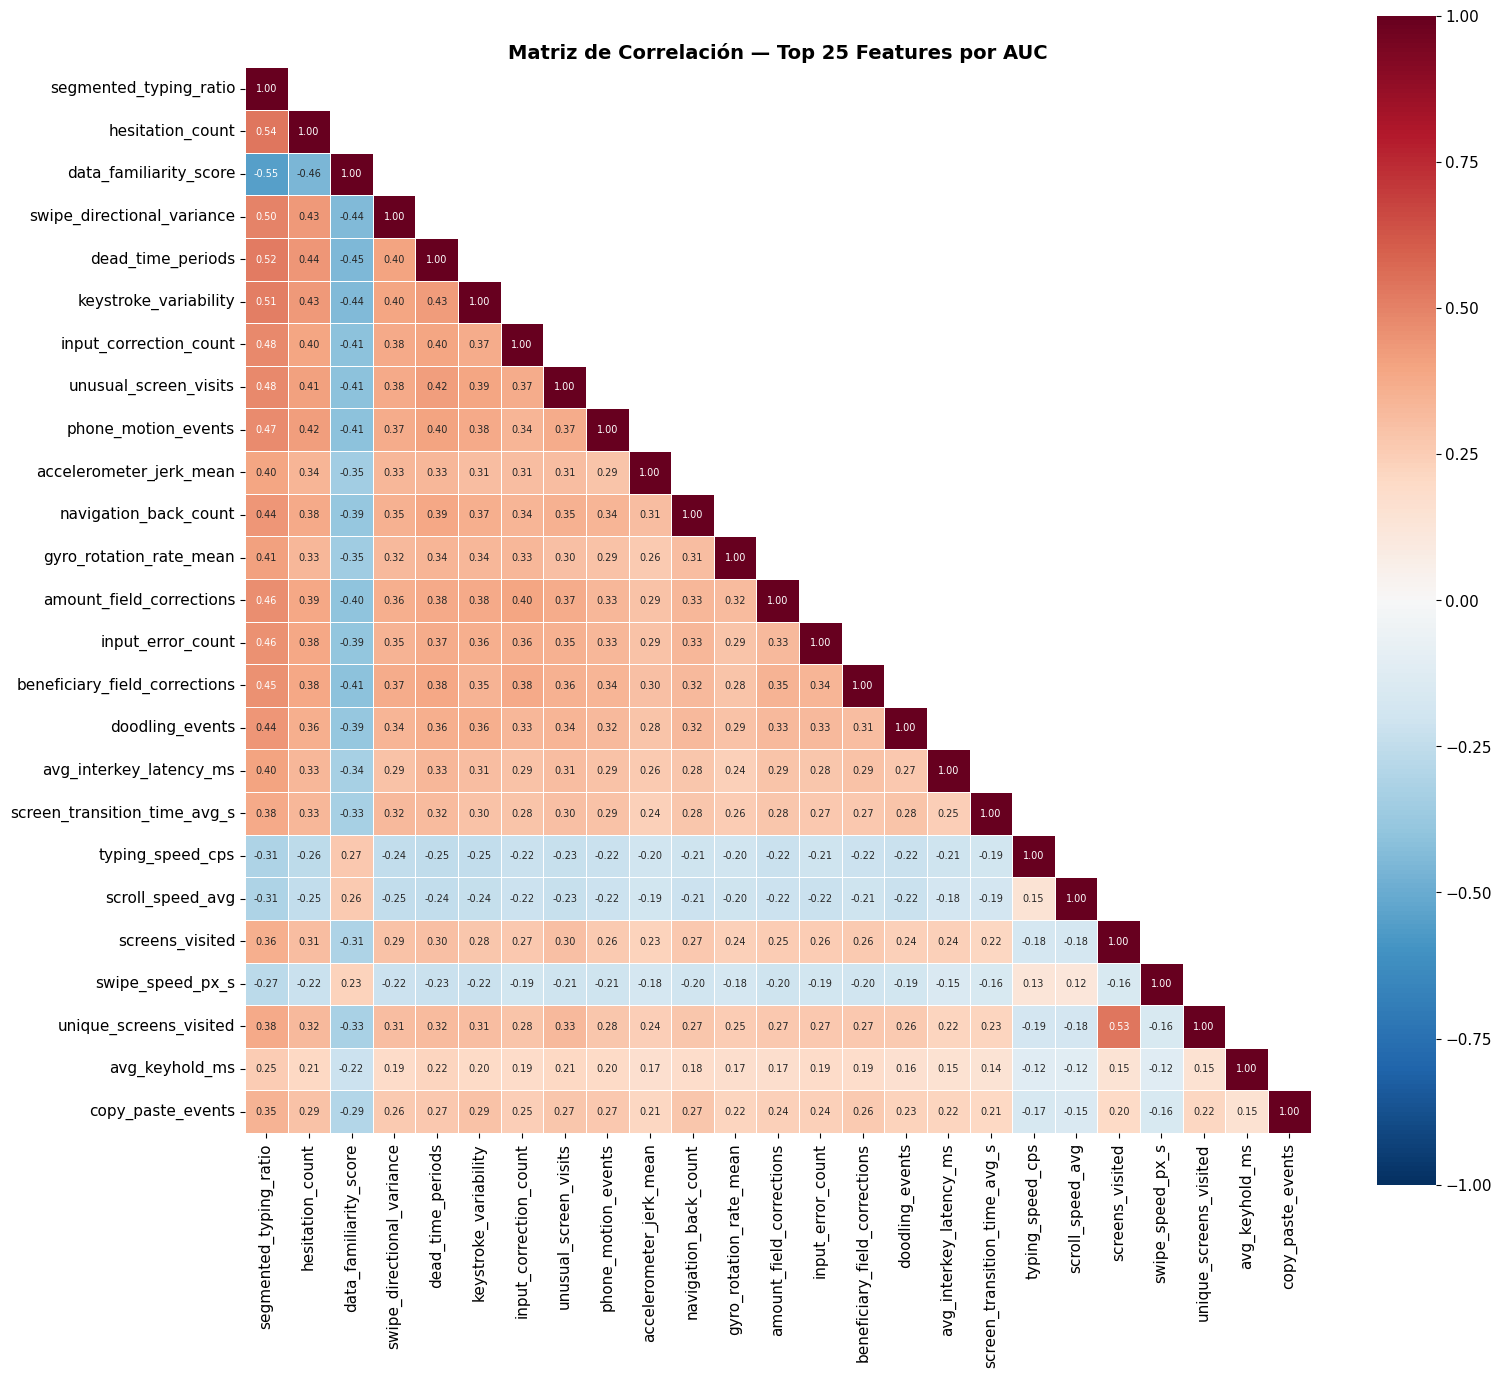

In [19]:
# 8.1 Matriz de correlación de las top 25 features
top25_feats = df_stats.nlargest(25, 'auc_univariate')['feature'].tolist()
corr_matrix = df[top25_feats].corr()

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 7}, vmin=-1, vmax=1)
ax.set_title('Matriz de Correlación — Top 25 Features por AUC', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

In [20]:
# 8.2 Identificar pares altamente correlacionados (|r| > 0.7)
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            high_corr.append({
                'feature_1': corr_matrix.columns[i],
                'feature_2': corr_matrix.columns[j],
                'correlation': r
            })

df_high_corr = pd.DataFrame(high_corr).sort_values('correlation', key=abs, ascending=False)

print(f'Pares con |correlación| > 0.7: {len(df_high_corr)}')
print()
if len(df_high_corr) > 0:
    for _, row in df_high_corr.iterrows():
        print(f"  {row['feature_1']:35s} ↔ {row['feature_2']:35s}  r={row['correlation']:+.3f}")
    print('\n⚠️  Considerar eliminar una de cada par o usar PCA para evitar multicolinealidad.')
else:
    print('  ✅ No se encontraron pares con correlación > 0.7')

KeyError: 'correlation'

## 9. Análisis Bivariado — Scatterplots e Interacciones

Exploramos relaciones entre pares de features clave para identificar patrones de separación no lineales.

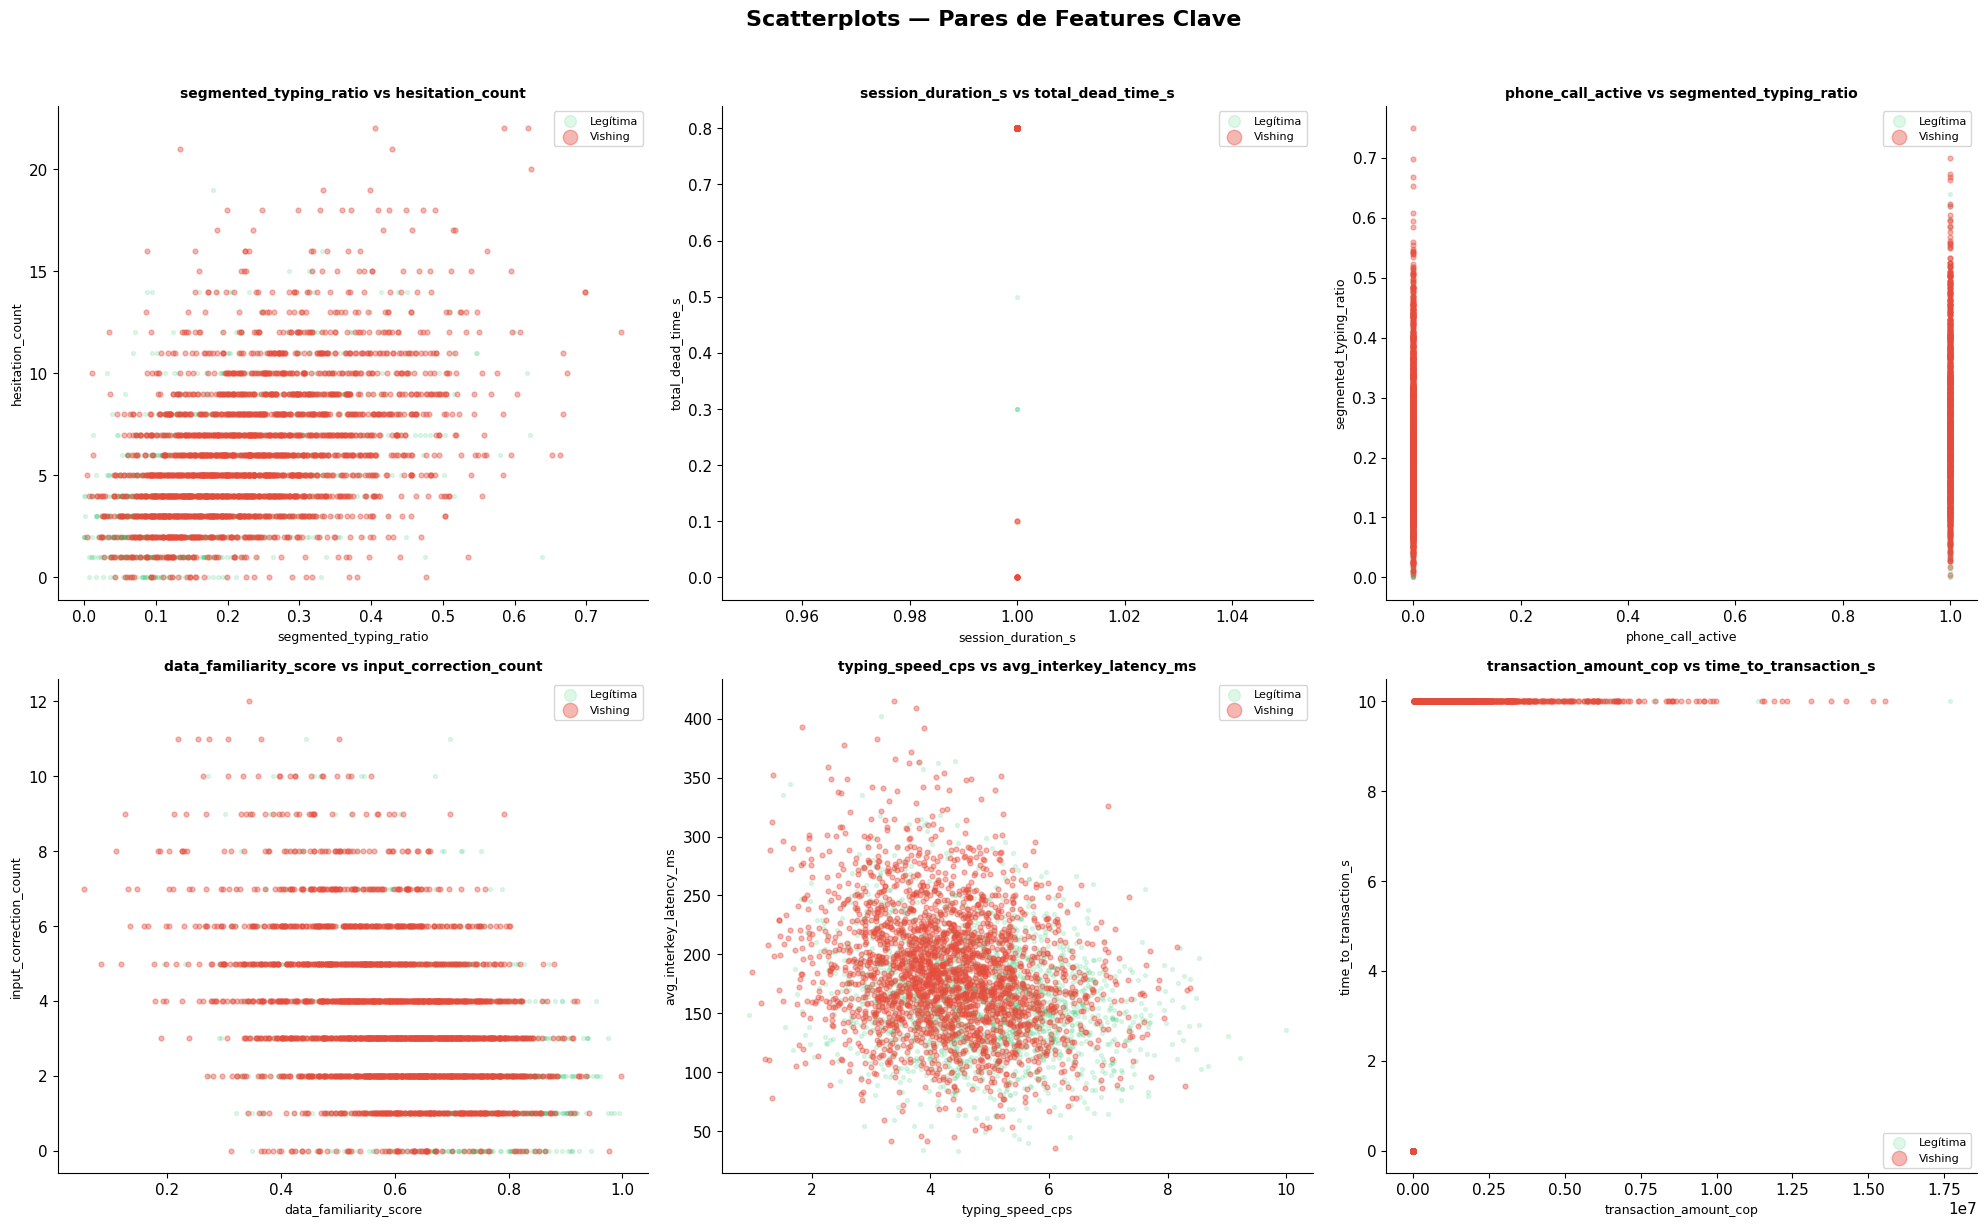

In [21]:
# 9.1 Scatterplots de pares clave
pairs = [
    ('segmented_typing_ratio', 'hesitation_count'),
    ('session_duration_s', 'total_dead_time_s'),
    ('phone_call_active', 'segmented_typing_ratio'),
    ('data_familiarity_score', 'input_correction_count'),
    ('typing_speed_cps', 'avg_interkey_latency_ms'),
    ('transaction_amount_cop', 'time_to_transaction_s'),
]

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.ravel()

for i, (x_feat, y_feat) in enumerate(pairs):
    ax = axes[i]
    # Subsample para legítimas (demasiados puntos)
    legit_sample = df_legit.sample(min(2000, len(df_legit)), random_state=42)
    
    ax.scatter(legit_sample[x_feat], legit_sample[y_feat], c=COLORS['legit'],
              alpha=0.15, s=8, label='Legítima')
    ax.scatter(df_vishing[x_feat], df_vishing[y_feat], c=COLORS['vishing'],
              alpha=0.4, s=12, label='Vishing')
    ax.set_xlabel(x_feat, fontsize=9)
    ax.set_ylabel(y_feat, fontsize=9)
    ax.set_title(f'{x_feat} vs {y_feat}', fontweight='bold', fontsize=10)
    ax.legend(fontsize=8, markerscale=3)

plt.suptitle('Scatterplots — Pares de Features Clave', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 10. Perfil Comportamental de una Sesión de Vishing

Construimos el perfil estadístico comparativo: ¿cómo se ve una sesión de vishing 
frente a una sesión legítima en promedio?

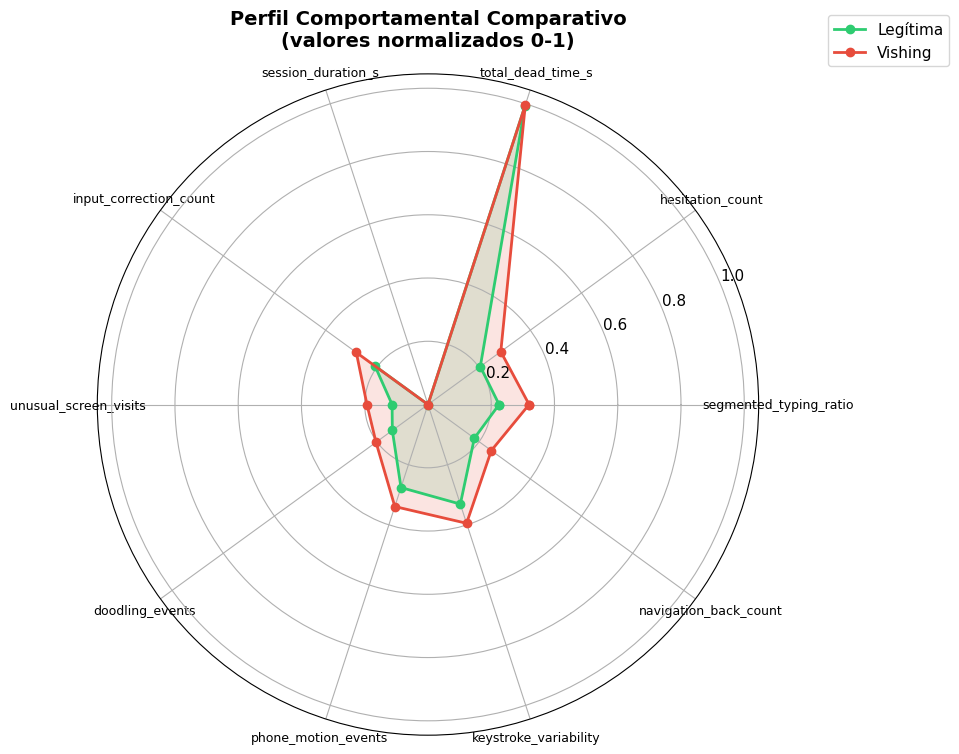

In [22]:
# Radar chart / perfil comparativo
profile_features = [
    'segmented_typing_ratio', 'hesitation_count', 'total_dead_time_s',
    'session_duration_s', 'input_correction_count', 'unusual_screen_visits',
    'doodling_events', 'phone_motion_events', 'keystroke_variability',
    'navigation_back_count'
]

# Normalizar a 0-1 para comparación visual
profile_data = []
for feat in profile_features:
    global_min = df[feat].min()
    global_max = df[feat].max()
    rng = global_max - global_min if global_max > global_min else 1
    legit_norm = (df_legit[feat].mean() - global_min) / rng
    vishing_norm = (df_vishing[feat].mean() - global_min) / rng
    profile_data.append({'feature': feat, 'legit': legit_norm, 'vishing': vishing_norm})

df_profile = pd.DataFrame(profile_data)

# Radar chart
angles = np.linspace(0, 2 * np.pi, len(profile_features), endpoint=False).tolist()
angles += angles[:1]  # cerrar el polígono

legit_vals = df_profile['legit'].tolist() + [df_profile['legit'].iloc[0]]
vishing_vals = df_profile['vishing'].tolist() + [df_profile['vishing'].iloc[0]]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
ax.plot(angles, legit_vals, 'o-', color=COLORS['legit'], linewidth=2, label='Legítima', markersize=6)
ax.fill(angles, legit_vals, alpha=0.15, color=COLORS['legit'])
ax.plot(angles, vishing_vals, 'o-', color=COLORS['vishing'], linewidth=2, label='Vishing', markersize=6)
ax.fill(angles, vishing_vals, alpha=0.15, color=COLORS['vishing'])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(profile_features, fontsize=9)
ax.set_title('Perfil Comportamental Comparativo\n(valores normalizados 0-1)',
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
plt.tight_layout()
plt.show()

In [23]:
# Tabla resumen del perfil
print('PERFIL COMPARATIVO — MEDIANA POR CLASE')
print('='*90)
print(f'{"Feature":40s} {"Legítima":>12s} {"Vishing":>12s} {"Ratio":>10s} {"Dirección":>12s}')
print('-'*90)

key_features = [
    'phone_call_active', 'segmented_typing_ratio', 'session_duration_s',
    'hesitation_count', 'avg_hesitation_duration_s', 'total_dead_time_s',
    'data_familiarity_score', 'typing_speed_cps', 'input_correction_count',
    'unusual_screen_visits', 'transaction_amount_cop', 'is_new_beneficiary',
    'doodling_events', 'phone_motion_events', 'keystroke_variability',
    'navigation_back_count', 'amount_field_corrections', 'beneficiary_field_corrections',
]

for feat in key_features:
    med_l = df_legit[feat].median()
    med_v = df_vishing[feat].median()
    ratio = med_v / med_l if med_l != 0 else float('inf')
    direction = '↑ MAYOR' if med_v > med_l else '↓ MENOR' if med_v < med_l else '= IGUAL'
    print(f'{feat:40s} {med_l:12.2f} {med_v:12.2f} {ratio:10.2f}x {direction:>12s}')

PERFIL COMPARATIVO — MEDIANA POR CLASE
Feature                                      Legítima      Vishing      Ratio    Dirección
------------------------------------------------------------------------------------------
phone_call_active                                0.00         0.00        infx      = IGUAL
segmented_typing_ratio                           0.15         0.23       1.51x      ↑ MAYOR
session_duration_s                               1.00         1.00       1.00x      = IGUAL
hesitation_count                                 4.00         6.00       1.50x      ↑ MAYOR
avg_hesitation_duration_s                        1.00         1.00       1.00x      = IGUAL
total_dead_time_s                                0.80         0.80       1.00x      = IGUAL
data_familiarity_score                           0.67         0.60       0.89x      ↓ MENOR
typing_speed_cps                                 4.73         4.30       0.91x      ↓ MENOR
input_correction_count                     

## 11. Análisis de Transacciones

Sesiones con transacción: 27,989
  Legítimas: 26,416 (55.6% del total legítimas)
  Vishing:   1,573 (62.9% del total vishing)


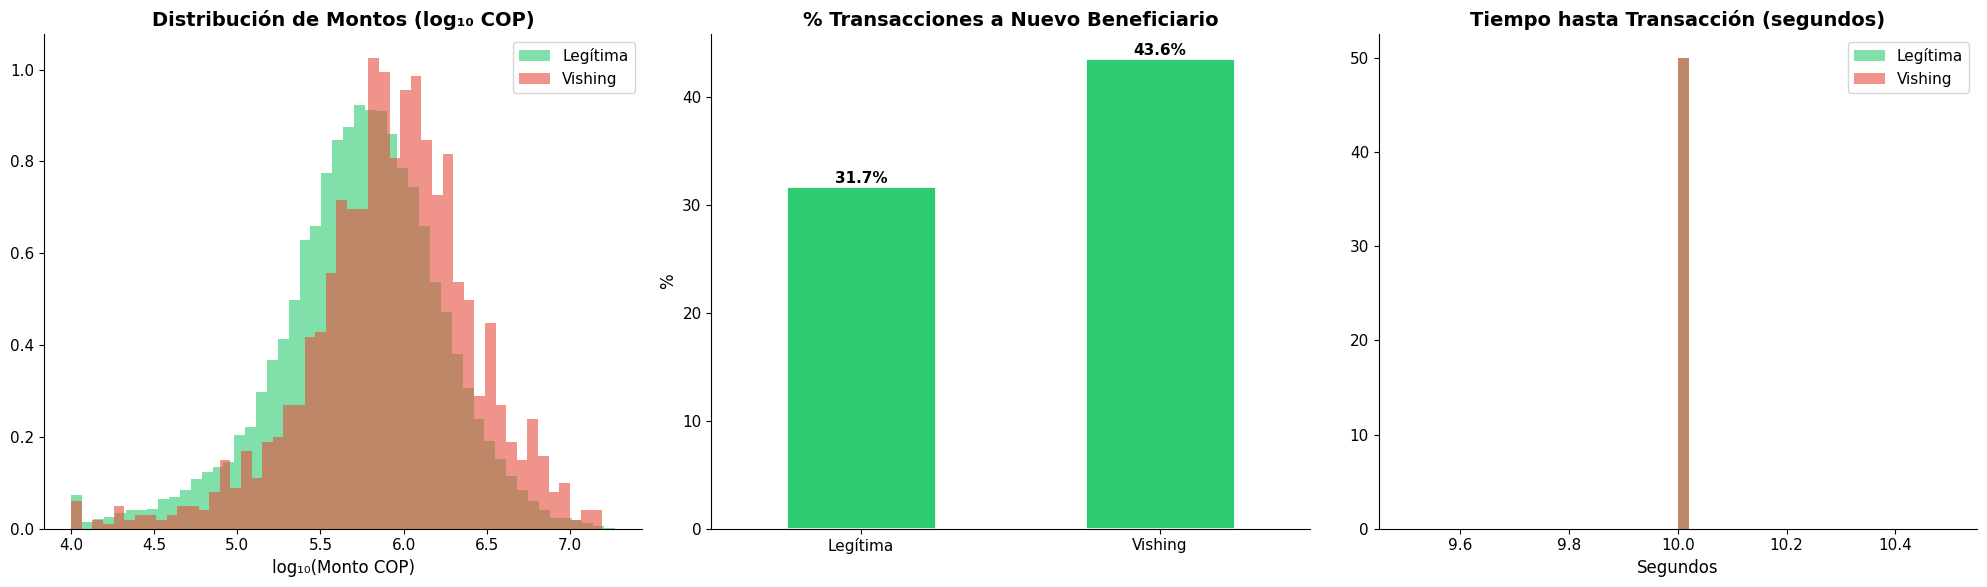

In [24]:
# Filtrar solo sesiones con transacción
df_tx = df[df['transaction_attempted'] == 1].copy()
df_tx_legit = df_tx[df_tx['is_vishing'] == 0]
df_tx_vishing = df_tx[df_tx['is_vishing'] == 1]

print(f'Sesiones con transacción: {len(df_tx):,}')
print(f'  Legítimas: {len(df_tx_legit):,} ({len(df_tx_legit)/len(df_legit)*100:.1f}% del total legítimas)')
print(f'  Vishing:   {len(df_tx_vishing):,} ({len(df_tx_vishing)/len(df_vishing)*100:.1f}% del total vishing)')

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Distribución de montos (log scale)
for subset, color, label in [(df_tx_legit, COLORS['legit'], 'Legítima'),
                              (df_tx_vishing, COLORS['vishing'], 'Vishing')]:
    amounts = subset['transaction_amount_cop']
    amounts = amounts[amounts > 0]
    axes[0].hist(np.log10(amounts), bins=50, alpha=0.6, color=color,
                 label=label, density=True, edgecolor='none')

axes[0].set_title('Distribución de Montos (log₁₀ COP)', fontweight='bold')
axes[0].set_xlabel('log₁₀(Monto COP)')
axes[0].legend()

# Nuevo beneficiario
new_ben_rates = pd.DataFrame({
    'Legítima': [df_tx_legit['is_new_beneficiary'].mean() * 100],
    'Vishing': [df_tx_vishing['is_new_beneficiary'].mean() * 100],
}).T
new_ben_rates.columns = ['% Nuevo beneficiario']
new_ben_rates.plot(kind='bar', ax=axes[1], color=[COLORS['legit'], COLORS['vishing']],
                   edgecolor='white', linewidth=2, legend=False)
axes[1].set_title('% Transacciones a Nuevo Beneficiario', fontweight='bold')
axes[1].set_ylabel('%')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

# Tiempo hasta transacción
for subset, color, label in [(df_tx_legit, COLORS['legit'], 'Legítima'),
                              (df_tx_vishing, COLORS['vishing'], 'Vishing')]:
    axes[2].hist(subset['time_to_transaction_s'], bins=50, alpha=0.6, color=color,
                 label=label, density=True, edgecolor='none')
axes[2].set_title('Tiempo hasta Transacción (segundos)', fontweight='bold')
axes[2].set_xlabel('Segundos')
axes[2].legend()

plt.tight_layout()
plt.show()

## 12. Análisis de Componentes Principales (PCA)

Proyectamos las features a 2D para visualizar la separabilidad global de las clases.

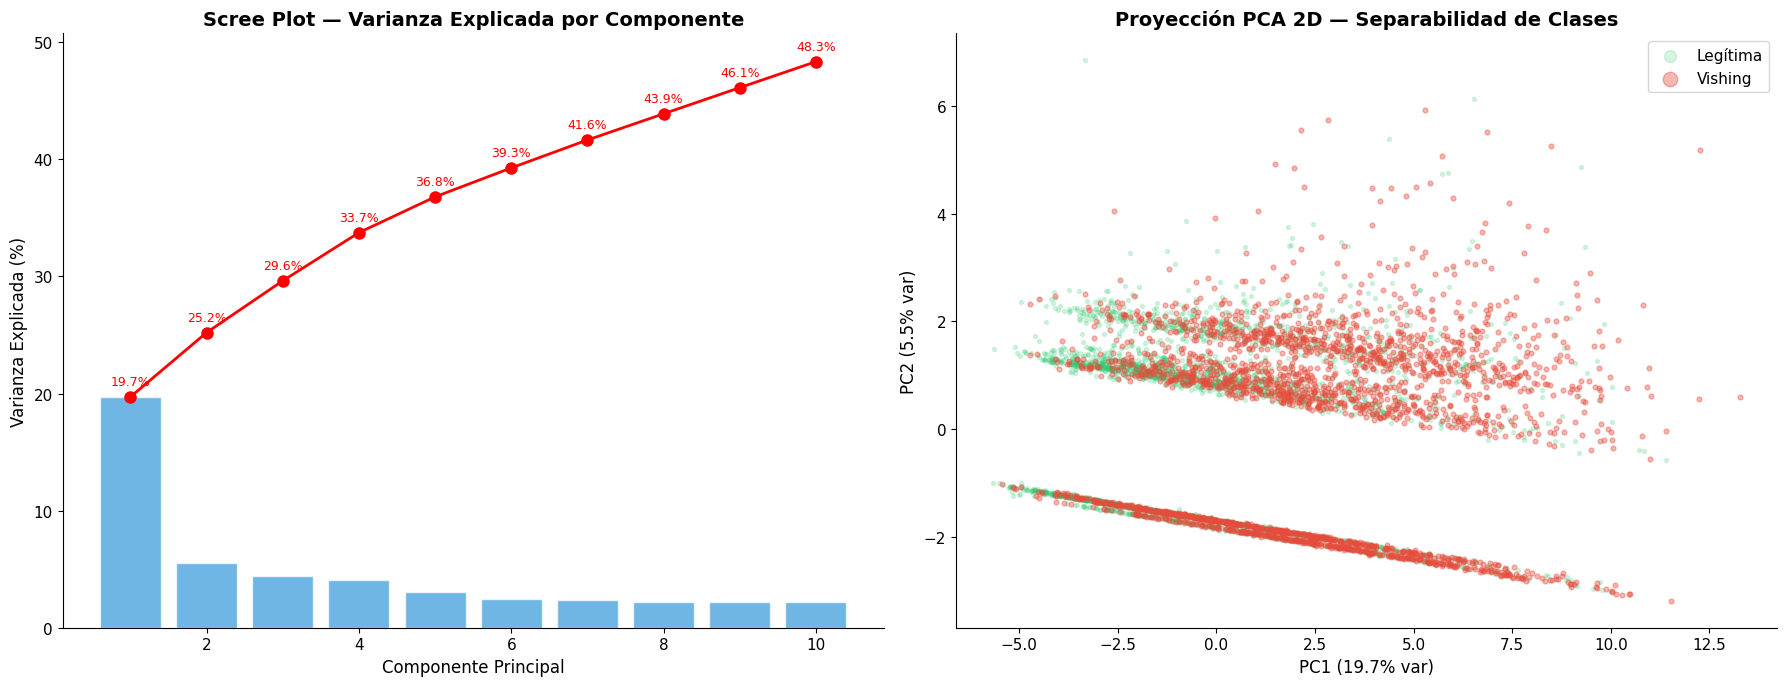


Varianza acumulada con 5 componentes: 36.8%
Varianza acumulada con 10 componentes: 48.3%


In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Seleccionar features numéricas (excluir labels y scores BioCatch)
pca_features = [c for c in numeric_cols if c not in exclude + ['hour_of_day']]

X = df[pca_features].fillna(0).values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Scree plot
explained = pca.explained_variance_ratio_ * 100
cumulative = np.cumsum(explained)
axes[0].bar(range(1, 11), explained, color=COLORS['neutral'], edgecolor='white', alpha=0.7)
axes[0].plot(range(1, 11), cumulative, 'ro-', linewidth=2, markersize=8)
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Varianza Explicada (%)')
axes[0].set_title('Scree Plot — Varianza Explicada por Componente', fontweight='bold')
for i, (e, c) in enumerate(zip(explained, cumulative)):
    axes[0].text(i+1, c+1, f'{c:.1f}%', ha='center', fontsize=9, color='red')

# 2D projection
idx_legit = df['is_vishing'].values == 0
idx_vishing = df['is_vishing'].values == 1

# Subsample legit para visualización
legit_idx = np.where(idx_legit)[0]
legit_sample_idx = np.random.choice(legit_idx, size=3000, replace=False)

axes[1].scatter(X_pca[legit_sample_idx, 0], X_pca[legit_sample_idx, 1],
               c=COLORS['legit'], alpha=0.2, s=8, label='Legítima')
axes[1].scatter(X_pca[idx_vishing, 0], X_pca[idx_vishing, 1],
               c=COLORS['vishing'], alpha=0.4, s=12, label='Vishing')
axes[1].set_xlabel(f'PC1 ({explained[0]:.1f}% var)')
axes[1].set_ylabel(f'PC2 ({explained[1]:.1f}% var)')
axes[1].set_title('Proyección PCA 2D — Separabilidad de Clases', fontweight='bold')
axes[1].legend(markerscale=3)

plt.tight_layout()
plt.show()

print(f'\nVarianza acumulada con 5 componentes: {cumulative[4]:.1f}%')
print(f'Varianza acumulada con 10 componentes: {cumulative[9]:.1f}%')

In [26]:
# Top features por loading en PC1 y PC2
loadings = pd.DataFrame(pca.components_[:2].T, columns=['PC1', 'PC2'], index=pca_features)
loadings['PC1_abs'] = loadings['PC1'].abs()
loadings['PC2_abs'] = loadings['PC2'].abs()

print('TOP 10 FEATURES POR LOADING EN PC1 (componente principal de separación):')
print(loadings.nlargest(10, 'PC1_abs')[['PC1']].to_string())
print(f'\nTOP 10 FEATURES POR LOADING EN PC2:')
print(loadings.nlargest(10, 'PC2_abs')[['PC2']].to_string())

TOP 10 FEATURES POR LOADING EN PC1 (componente principal de separación):
                                 PC1
segmented_typing_ratio      0.266094
data_familiarity_score     -0.235191
hesitation_count            0.231605
dead_time_periods           0.225996
keystroke_variability       0.219927
swipe_directional_variance  0.216477
unusual_screen_visits       0.213325
input_correction_count      0.208913
phone_motion_events         0.204401
amount_field_corrections    0.202908

TOP 10 FEATURES POR LOADING EN PC2:
                              PC2
transaction_attempted    0.599218
time_to_transaction_s    0.599218
transaction_amount_cop   0.366553
is_new_beneficiary       0.361222
phone_call_active       -0.039207
call_overlap_duration_s -0.039207
segmented_typing_ratio  -0.030794
phone_motion_events     -0.029292
hesitation_count        -0.028861
dead_time_periods       -0.028479


## 13. Detección de Outliers

In [27]:
# Análisis de outliers usando IQR
outlier_features = [
    'session_duration_s', 'transaction_amount_cop', 'hesitation_count',
    'total_dead_time_s', 'typing_speed_cps', 'biocatch_risk_score'
]

print('ANÁLISIS DE OUTLIERS (método IQR, umbral 1.5×IQR)')
print('='*80)

for feat in outlier_features:
    Q1 = df[feat].quantile(0.25)
    Q3 = df[feat].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[feat] < lower) | (df[feat] > upper)]
    n_outliers = len(outliers)
    pct_vishing_in_outliers = outliers['is_vishing'].mean() * 100 if n_outliers > 0 else 0
    
    print(f'\n  {feat}:')
    print(f'    IQR: [{Q1:.1f}, {Q3:.1f}], bounds: [{lower:.1f}, {upper:.1f}]')
    print(f'    Outliers: {n_outliers:,} ({n_outliers/len(df)*100:.2f}%)')
    print(f'    % vishing entre outliers: {pct_vishing_in_outliers:.1f}% (vs {df["is_vishing"].mean()*100:.1f}% global)')

ANÁLISIS DE OUTLIERS (método IQR, umbral 1.5×IQR)

  session_duration_s:
    IQR: [1.0, 1.0], bounds: [1.0, 1.0]
    Outliers: 0 (0.00%)
    % vishing entre outliers: 0.0% (vs 5.0% global)

  transaction_amount_cop:
    IQR: [0.0, 675137.5], bounds: [-1012706.2, 1687843.8]
    Outliers: 4,054 (8.11%)
    % vishing entre outliers: 9.8% (vs 5.0% global)

  hesitation_count:
    IQR: [3.0, 6.0], bounds: [-1.5, 10.5]
    Outliers: 1,885 (3.77%)
    % vishing entre outliers: 14.7% (vs 5.0% global)

  total_dead_time_s:
    IQR: [0.8, 0.8], bounds: [0.8, 0.8]
    Outliers: 369 (0.74%)
    % vishing entre outliers: 3.0% (vs 5.0% global)

  typing_speed_cps:
    IQR: [3.9, 5.6], bounds: [1.3, 8.1]
    Outliers: 412 (0.82%)
    % vishing entre outliers: 2.4% (vs 5.0% global)

  biocatch_risk_score:
    IQR: [157.0, 402.0], bounds: [-210.5, 769.5]
    Outliers: 267 (0.53%)
    % vishing entre outliers: 28.1% (vs 5.0% global)


## 14. Feature Importance Preliminar (Random Forest rápido)

Entrenamos un Random Forest rápido para obtener una primera estimación de importancia relativa de features. 
Esto no es modelado formal — es exploración.

Random Forest — 5-fold CV AUC: 0.7194 ± 0.0099


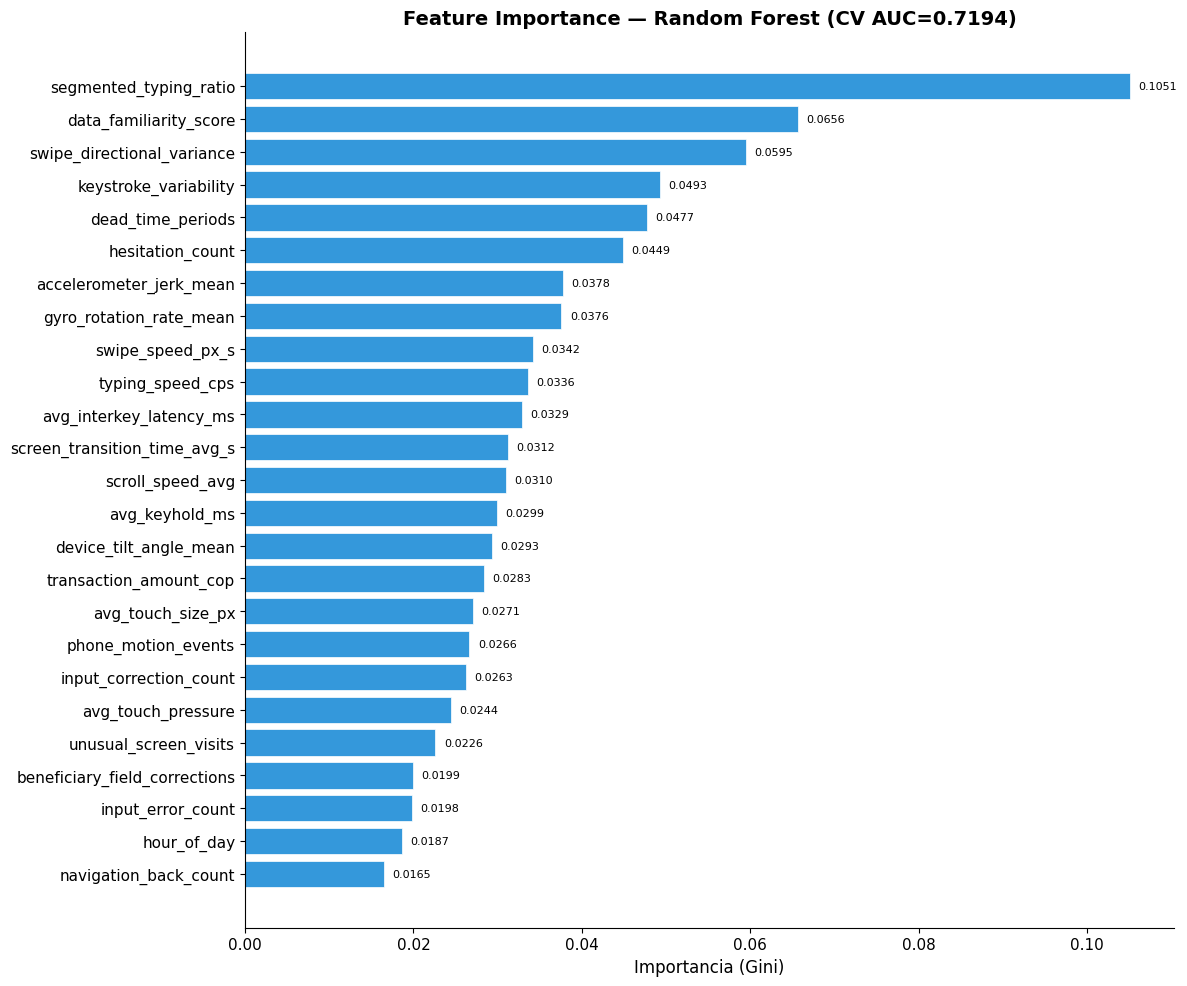

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Preparar features
model_features = [c for c in numeric_cols if c not in exclude]
X_rf = df[model_features].fillna(0).values
y_rf = df['is_vishing'].values

# Random Forest rápido
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42,
                            class_weight='balanced', n_jobs=-1)
rf.fit(X_rf, y_rf)

# Cross-validation score
cv_scores = cross_val_score(rf, X_rf, y_rf, cv=5, scoring='roc_auc', n_jobs=-1)
print(f'Random Forest — 5-fold CV AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

# Feature importance
fi = pd.DataFrame({
    'feature': model_features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(12, 10))
top_fi = fi.head(25)
ax.barh(range(len(top_fi)), top_fi['importance'].values, color=COLORS['neutral'],
        edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(top_fi)))
ax.set_yticklabels(top_fi['feature'].values)
ax.set_xlabel('Importancia (Gini)')
ax.set_title(f'Feature Importance — Random Forest (CV AUC={cv_scores.mean():.4f})',
             fontweight='bold')
ax.invert_yaxis()

for i, v in enumerate(top_fi['importance'].values):
    ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()